# **Kaggle Challenge 2: Đề tài dự báo giá nhà.**
# **PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU**

## 1. Mô tả vấn đề
+ **Mô tả**:
   - Dự báo giá nhà dựa trên 79 tính chất của dataset nhà ở tại Ames, Iowa.
   - Dữ liệu đầu vào gồm 2 file:
      * train_clean.pkl: Dữ liệu từ file train đã được xử lý ở phần 1.
      * test_clean.pkl: Dữ liệu từ file test đã được xử lý ở phần 1.

+ **Mục tiêu**:
   - Phân tích và khám phá, tìm đặc trưng của các cột trong dữ liệu.



## 2. Chuẩn bị                

### 2.1. Import các thư viện cần thiết

In [2]:
# Load libraries
from IPython import display
import numpy as np
import pickle

import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns


### 2.2. Đọc dataset train và test từ dataset đã xử lý trong phần dọn dẹp dữ liệu
Đọc các file .pkl trong thư mục /clean/data

In [3]:
train_data = pd.DataFrame(pd.read_pickle("../clean/data/train_clean.pkl"))
test_data = pd.DataFrame(pd.read_pickle("../clean/data/test_clean.pkl"))

### 2.3. Kiểm tra dữ liệu dataset train và test

In [4]:
train_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,20,RL,80,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,60,RL,68,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,70,RL,60,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,60,RL,84,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,2008,WD,Normal,250000


In [5]:
test_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,120,0,None,MnPrv,None,0,6,2010,WD,Normal
1,20,RL,81,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,0,None,None,Gar2,12500,6,2010,WD,Normal
2,60,RL,74,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,None,MnPrv,None,0,3,2010,WD,Normal
3,60,RL,78,9978,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,None,None,None,0,6,2010,WD,Normal
4,120,RL,43,5005,Pave,None,IR1,HLS,AllPub,Inside,...,144,0,None,None,None,0,1,2010,WD,Normal


In [6]:
print("Số cột null trong train: ", train_data.isnull().sum().gt(0).sum())
print("Số cột null trong test: ", test_data.isnull().sum().gt(0).sum())

Số cột null trong train:  0
Số cột null trong test:  0


In [7]:
train_data.dtypes.value_counts()

object    43
int64     37
Name: count, dtype: int64

In [8]:
test_data.dtypes.value_counts()

object    43
int64     36
Name: count, dtype: int64

## 3. Phân tích khai phá dữ liệu

### 3.1. Phân tích đơn biến

#### **1) Các cột số**

##### a. Phân phối các cột số theo biểu đồ cột (Histogram Plot)

In [9]:
# # Tạo lưới biểu đồ
# fig, axes = plt.subplots(10, 4, figsize=(20, 30))
# axes = axes.flatten()

# # Lặp qua các cột trong dataframe
# for i, col in enumerate(train_data.select_dtypes(include=['int64']).columns):
#     sns.histplot(train_data[col], bins=50, kde=True, color='skyblue', ax=axes[i])
#     axes[i].set_title(col, fontsize=10)
#     axes[i].set_xlabel('')
#     axes[i].set_ylabel('')

# # Xóa các subplot không dùng đến (dư thừa)
# for j in range(len(train_data.select_dtypes(include=['int64']).columns), len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.savefig("fig_hist_1a.png")
# plt.show()

**Nhận xét**
- Các cột MSSubClass, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, 
TotRmsAbvGrd, Fireplaces, GarageCars, MoSold và YrSold có phân bố rời rạc.
- Các cột LotFrontage, LotArea, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, 1stFlrSF,2ndFlrSF, LowQualFinSF, GrLivArea, GarageArea, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea và MiscVal có phân bố liên tục.
- Các cột YearBuilt, YearRemodAdd, GarageYrBlt, MoSold và YrSold là các cột thứ tự thời gian.
- Các cột OverallQual, OverallCond  là các cột có tính chất phân loại (đánh giá).

##### b. Phân phối các cột có phân bố liên tục theo biểu đồ hộp (Box plot)

In [10]:
# continous_cols = [
#     "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
#     "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
#     "GrLivArea", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
#     "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal"
# ]
# # Tạo lưới biểu đồ
# fig, axes = plt.subplots(5, 4, figsize=(20, 20))
# axes = axes.flatten()

# # Lặp qua các cột trong dataframe
# for i, col in enumerate(train_data[continous_cols]):
#     sns.boxplot(train_data[col], color="skyblue", fliersize=3, linewidth=1, ax=axes[i])
#     axes[i].set_title(col, fontsize=10)
#     axes[i].set_xlabel('')
#     axes[i].set_ylabel('')

# # Xóa các subplot không dùng đến (dư thừa)
# for j in range(len(continous_cols), len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.savefig("fig_box_1a.png")
# plt.show()

**Nhận xét**
+ Các cột MasVnrArea, BsmtFinSF1, BsmtFinSF2, 2ndFlrSF, LowQualFinSF, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, 
ScreenPorch, PoolArea, MiscVal có phân bố lệch phải mạnh với nhiều giá trị ngoại lai (có phân phối hình chữ L). Giá trị
tập trung hầu hết ở 0 (0 ở đây có khả năng là không có).
+ Các cột LotArea, LotFrontage, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, GrLivArea, GarageArea có phân bố ổn định hơn nhưng vẫn lệch phải với nhiều giá trị ngoại lai. 

##### c. Xem phân phối giá trị các cột phân phối rời rạc

In [11]:
discrete_cols = [
    "MSSubClass", 
    "BsmtFullBath", 
    "BsmtHalfBath", 
    "FullBath", 
    "HalfBath", 
    "BedroomAbvGr", 
    "KitchenAbvGr", 
    "TotRmsAbvGrd", 
    "Fireplaces", 
    "GarageCars"
]

for col in discrete_cols:
      print("-------------------------------")
      print(f"Phân phối cột {col} (train): ", train_data[col].sort_values().unique(), ", có", 
            train_data[col].unique().size, " giá trị ")
      print(f"Phân phối cột {col} (test): ", test_data[col].sort_values().unique(), ", có", 
            test_data[col].unique().size, " giá trị ")



-------------------------------
Phân phối cột MSSubClass (train):  [ 20  30  40  45  50  60  70  75  80  85  90 120 160 180 190] , có 15  giá trị 
Phân phối cột MSSubClass (test):  [ 20  30  40  45  50  60  70  75  80  85  90 120 150 160 180 190] , có 16  giá trị 
-------------------------------
Phân phối cột BsmtFullBath (train):  [0 1 2 3] , có 4  giá trị 
Phân phối cột BsmtFullBath (test):  [0 1 2 3] , có 4  giá trị 
-------------------------------
Phân phối cột BsmtHalfBath (train):  [0 1 2] , có 3  giá trị 
Phân phối cột BsmtHalfBath (test):  [0 1 2] , có 3  giá trị 
-------------------------------
Phân phối cột FullBath (train):  [0 1 2 3] , có 4  giá trị 
Phân phối cột FullBath (test):  [0 1 2 3 4] , có 5  giá trị 
-------------------------------
Phân phối cột HalfBath (train):  [0 1 2] , có 3  giá trị 
Phân phối cột HalfBath (test):  [0 1 2] , có 3  giá trị 
-------------------------------
Phân phối cột BedroomAbvGr (train):  [0 1 2 3 4 5 6 8] , có 8  giá trị 
Phân phối cột Bed

**Nhận xét**: 
- Cột MSSubClass có 16 loại giá trị trên test, nhưng trong train chỉ có 15 giá trị(thiếu giá trị 150).
- Cột FullBath có 5 loại giá trị trên test, nhưng trong train chỉ có 4 giá trị(thiếu giá trị 4).
- Cột BedroomAbvGr có 7 loại giá trị trên test, nhưng trong train có 8 giá trị (dư giá trị 8).
- Cột KitchenAbvGr có 3 loại giá trị trên test, nhưng trong train có 4 giá trị (dư giá trị 3).
- Cột TotRmsAbvGrd có 12 loại giá trị trên test, trong train có 12 giá trị nhưng phân bố khác với test.
- Cột Fireplaces có 5 loại giá trị trên test, nhưng trong train chỉ có 4 giá trị (thiếu giá trị 4).
- Cột GarageCars có 6 loại giá trị trên test, nhưng trong train có 6 loại giá trị (thiếu giá trị 5).
- Cột BsmtFullBath, BsmtHalfBath, HalfBath có phân phối giống nhau trên cả train và test.

**Giá trị trong hầu hết các cột trừ MSSubClass đều biểu hiện quan hệ thứ tự hay khoảng cách nên model học máy tự suy ra được. Do đó, cột MSSubClass cần được xử lý riêng (do sự phân bố của nó được đề cập trong file mô tả).**

##### d. Xem phân phối của các cột phân loại (đánh giá)

In [12]:
for col in ["OverallQual", "OverallCond"]:
    print("-------------------------------")
    print(f"Phân phối cột {col} (train): ", train_data[col].sort_values().unique(), ", có", 
        train_data[col].unique().size, " giá trị ")
    print(f"Phân phối cột {col} (test): ", test_data[col].sort_values().unique(), ", có", 
        test_data[col].unique().size, " giá trị ")



-------------------------------
Phân phối cột OverallQual (train):  [ 1  2  3  4  5  6  7  8  9 10] , có 10  giá trị 
Phân phối cột OverallQual (test):  [ 1  2  3  4  5  6  7  8  9 10] , có 10  giá trị 
-------------------------------
Phân phối cột OverallCond (train):  [1 2 3 4 5 6 7 8 9] , có 9  giá trị 
Phân phối cột OverallCond (test):  [1 2 3 4 5 6 7 8 9] , có 9  giá trị 


**Nhận xét**: Cả 2 cột OverallQual và OverallCond đều phân phối giá trị giống nhau trên train và test

##### e. Xem phân phối các cột thứ tự thời gian

In [13]:
time_cols = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]

for col in time_cols:
    print("-------------------------------")
    
    train_vals = set(train_data[col].unique())
    test_vals = set(test_data[col].unique())
    
    print(f"Phân phối cột {col} (train): {sorted(train_vals)}, có {len(train_vals)} giá trị")
    print(f"Phân phối cột {col} (test): {sorted(test_vals)}, có {len(test_vals)} giá trị")
    
    # Giá trị có trong test nhưng không có trong train
    print(f"Giá trị chỉ có trong test: {sorted(test_vals - train_vals)}")
    
    # Giá trị có trong train nhưng không có trong test
    print(f"Giá trị chỉ có trong train: {sorted(train_vals - test_vals)}")

-------------------------------
Phân phối cột YearBuilt (train): [np.int64(1872), np.int64(1875), np.int64(1880), np.int64(1882), np.int64(1885), np.int64(1890), np.int64(1892), np.int64(1893), np.int64(1898), np.int64(1900), np.int64(1904), np.int64(1905), np.int64(1906), np.int64(1908), np.int64(1910), np.int64(1911), np.int64(1912), np.int64(1913), np.int64(1914), np.int64(1915), np.int64(1916), np.int64(1917), np.int64(1918), np.int64(1919), np.int64(1920), np.int64(1921), np.int64(1922), np.int64(1923), np.int64(1924), np.int64(1925), np.int64(1926), np.int64(1927), np.int64(1928), np.int64(1929), np.int64(1930), np.int64(1931), np.int64(1932), np.int64(1934), np.int64(1935), np.int64(1936), np.int64(1937), np.int64(1938), np.int64(1939), np.int64(1940), np.int64(1941), np.int64(1942), np.int64(1945), np.int64(1946), np.int64(1947), np.int64(1948), np.int64(1949), np.int64(1950), np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int

**Nhận xét**: 
- Các cột YearRemodAdd, MoSold, YrSold có phân phối giá trị giống nhau.
- Các cột YearBuilt, GarageYrBuilt biểu hiện quan hệ thứ tự, do đó không cần mã hóa One Hot.

#### **2) Các cột phi số**

In [14]:
train_data.select_dtypes(include=["object"]).columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

##### a. Cột MSZoning 

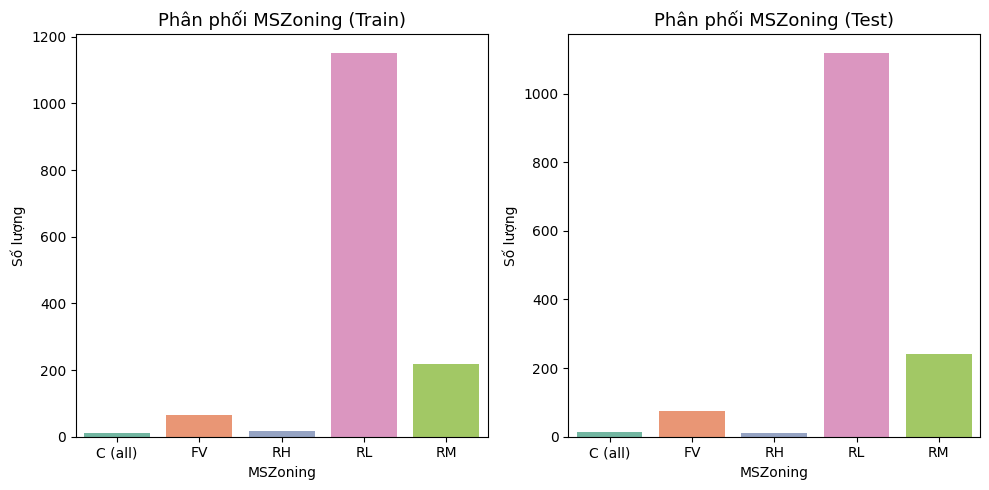

In [15]:
cols = ["MSZoning"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 5))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(1, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột MSZoning có 5 giá trị bao gồm (theo mô tả):
   + RM: Vùng dân cư mật độ trung bình.
   + RL: Vùng dân cư mật độ thấp.
   + RH: Vùng dân cư mật độ cao.
   + FV: Vùng nước nổi.
   + C(all): Trong file mô tả không đề cập tới giá trị này (chỉ có A, C, I và RP), có thể là giá trị C (Commercial).

- Giá trị RL phân bố nhiều nhất, giá trị C(all) và RH phân bố ít nhất.


##### b. Cột Street, PaveDrive và Alley

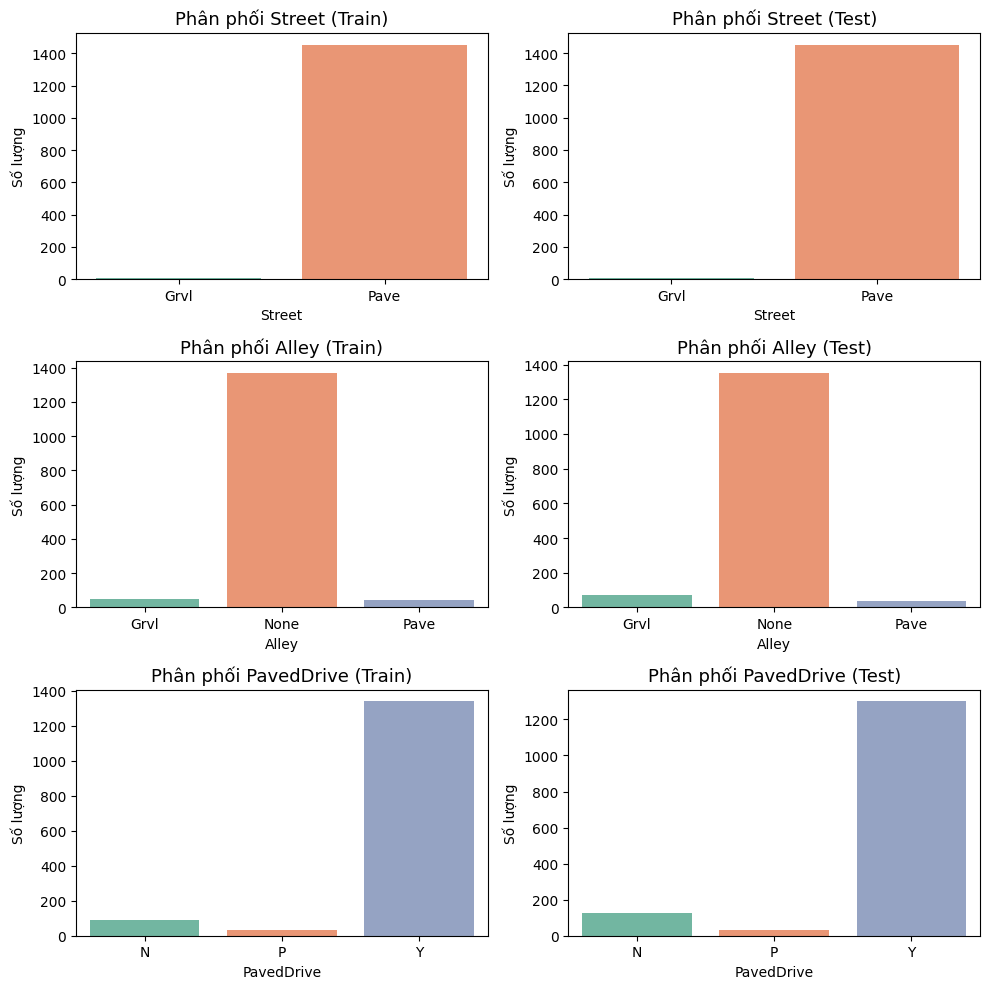

In [49]:
cols = ["Street", "Alley", "PavedDrive"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(3, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột Street có 2 giá trị bao gồm (theo mô tả):
   + Pave: Đường nhựa.
   + Grvl: Đường sỏi đá.
- Cột Alley có 3 giá trị bao gồm (theo mô tả):
   + None: Không có đường.
   + Pave: Đường nhựa.
   + Grvl: Đường bằng sỏi đá.
- Cột PaveDrive có 3 giá trị bao gồm (theo mô tả):
	+ Y: Được lát nhựa / bê tông (đường lái xe được trải nhựa hoàn toàn)
	+ P: Lát một phần (chỉ một phần được lát nhựa)
	+ N: Đất hoặc sỏi (chưa được lát)
- Trong Street, giá trị Pave phân bố nhiều nhất, giá trị Grvl phân bố ít nhất.
- Trong Alley, giá trị None phân bố nhiều nhất, giá trị Grvl và Pave phân bố ít nhất.
- Trong PaveDrive, giá trị Y phân bố nhiều nhất, giá trị P phân bố ít nhất.


##### c. Cột LotShape và LotConfig

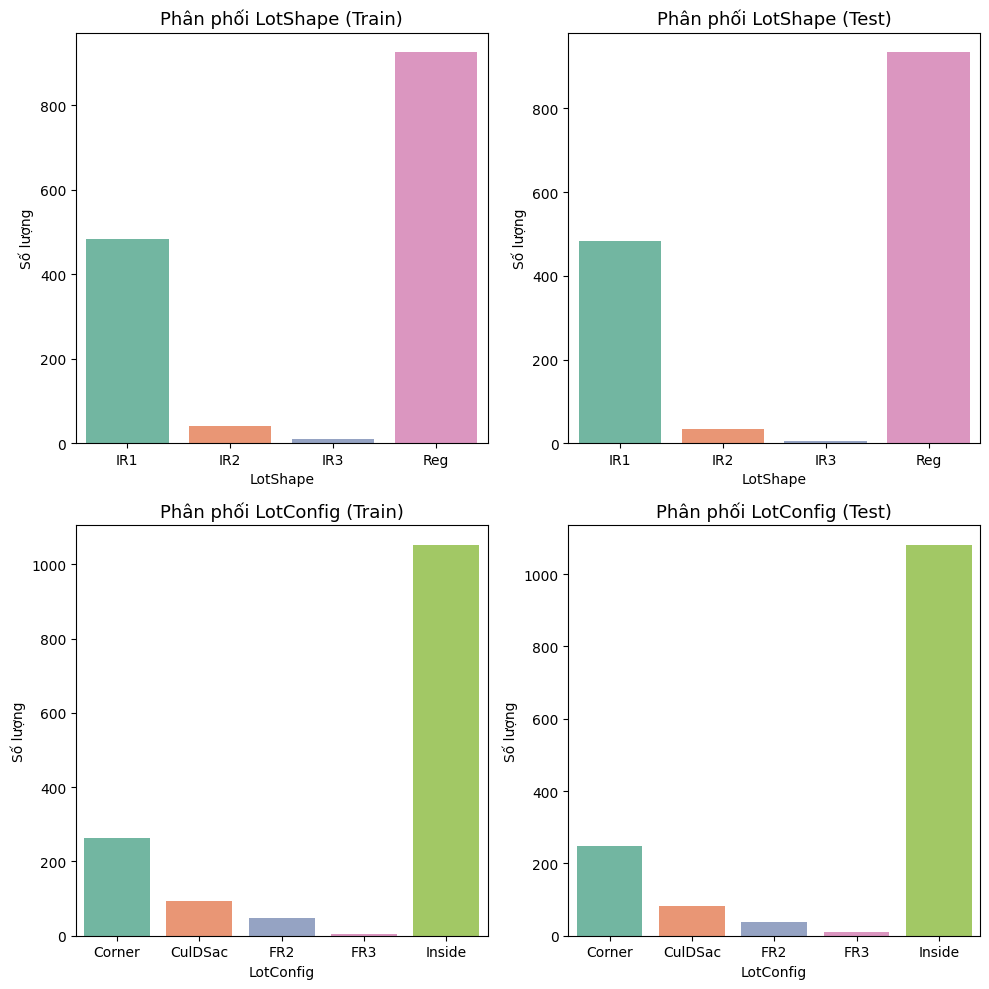

In [17]:
cols = ["LotShape", "LotConfig"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột LotShape có 4 giá trị bao gồm (theo mô tả):
   + Reg: Kích thước bình thường.
   + IR1: Kích thước hơi bất bình thường.
   + IR2: Kích thước bất bình thường.
   + IR3: Kích thước rất bất bình thường.
- Cột LotConfig có 5 giá trị bao gồm (theo mô tả):
   + Inside: Mặt tiền đường bên trong.
   + Corner: Mặt tiền đường bên góc.
   + CulDSac: Mặt tiền đường cụt.
   + FR2: Có 2 mặt tiền đường.
   + FR3: Có 3 mặt tiền đường.

- Giá trị Reg phân bố nhiều nhất, giá trị IR3 phân bố ít nhất.
- Giá trị Inside phân bố nhiều nhất, giá trị FR3 phân bố ít nhất.


##### d. Cột LandContour và LandSlope

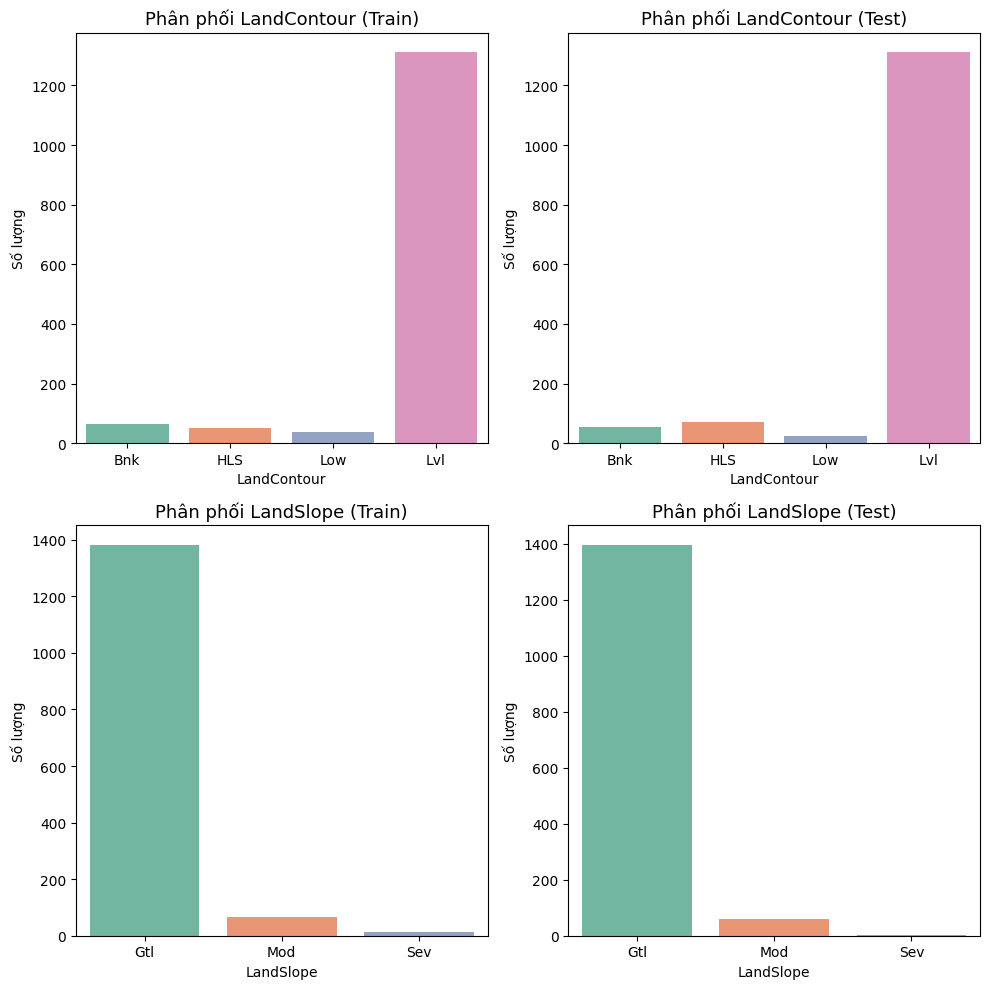

In [18]:
cols = ["LandContour", "LandSlope"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột LandContour có 4 giá trị bao gồm (theo mô tả):
   + Lvl: Gần bằng phằng.
   + Bnk: Hơi dốc.
   + HLS: Khá dốc.
   + Low: Rất dốc.
- Cột LandSlope có 3 giá trị bao gồm (theo mô tả):
   + Gtl: Hơi dốc.
   + Mod: Khá dốc.
   + Sev: Rất dốc.
- Giá trị Lvl phân bố nhiều nhất, giá trị Low phân bố ít nhất.
- Giá trị Gtl phân bố nhiều nhất, giá trị Sev phân bố ít nhất.

##### e. Cột Utilities

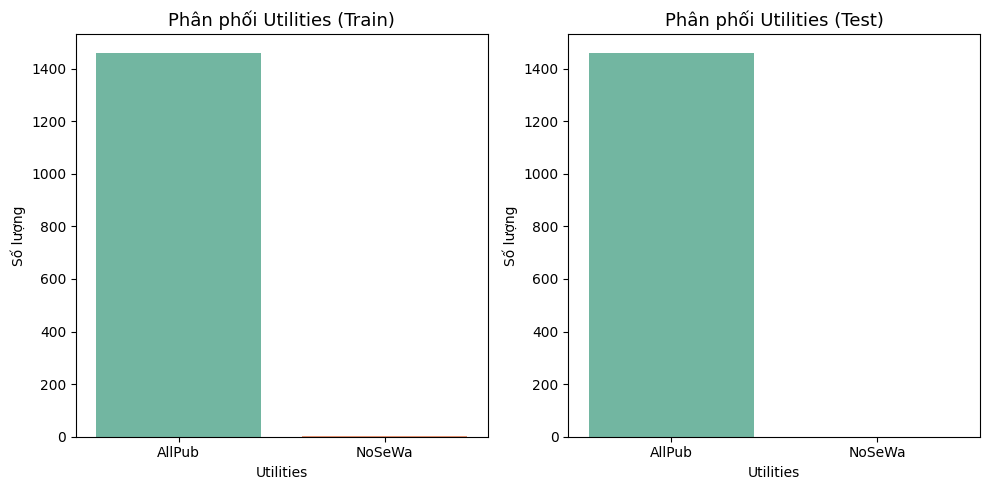

In [19]:
cols = ["Utilities"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 5))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(1, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột Utilities có 2 giá trị bao gồm (theo mô tả):
   + AllPub: Tất cả dịch vụ.
   + NoSeWa: Chỉ có điện và ga.
- Giá trị AllPub phân bố nhiều nhất, giá trị NoSeWa phân bố ít nhất.

##### f. Cột Neighborhood

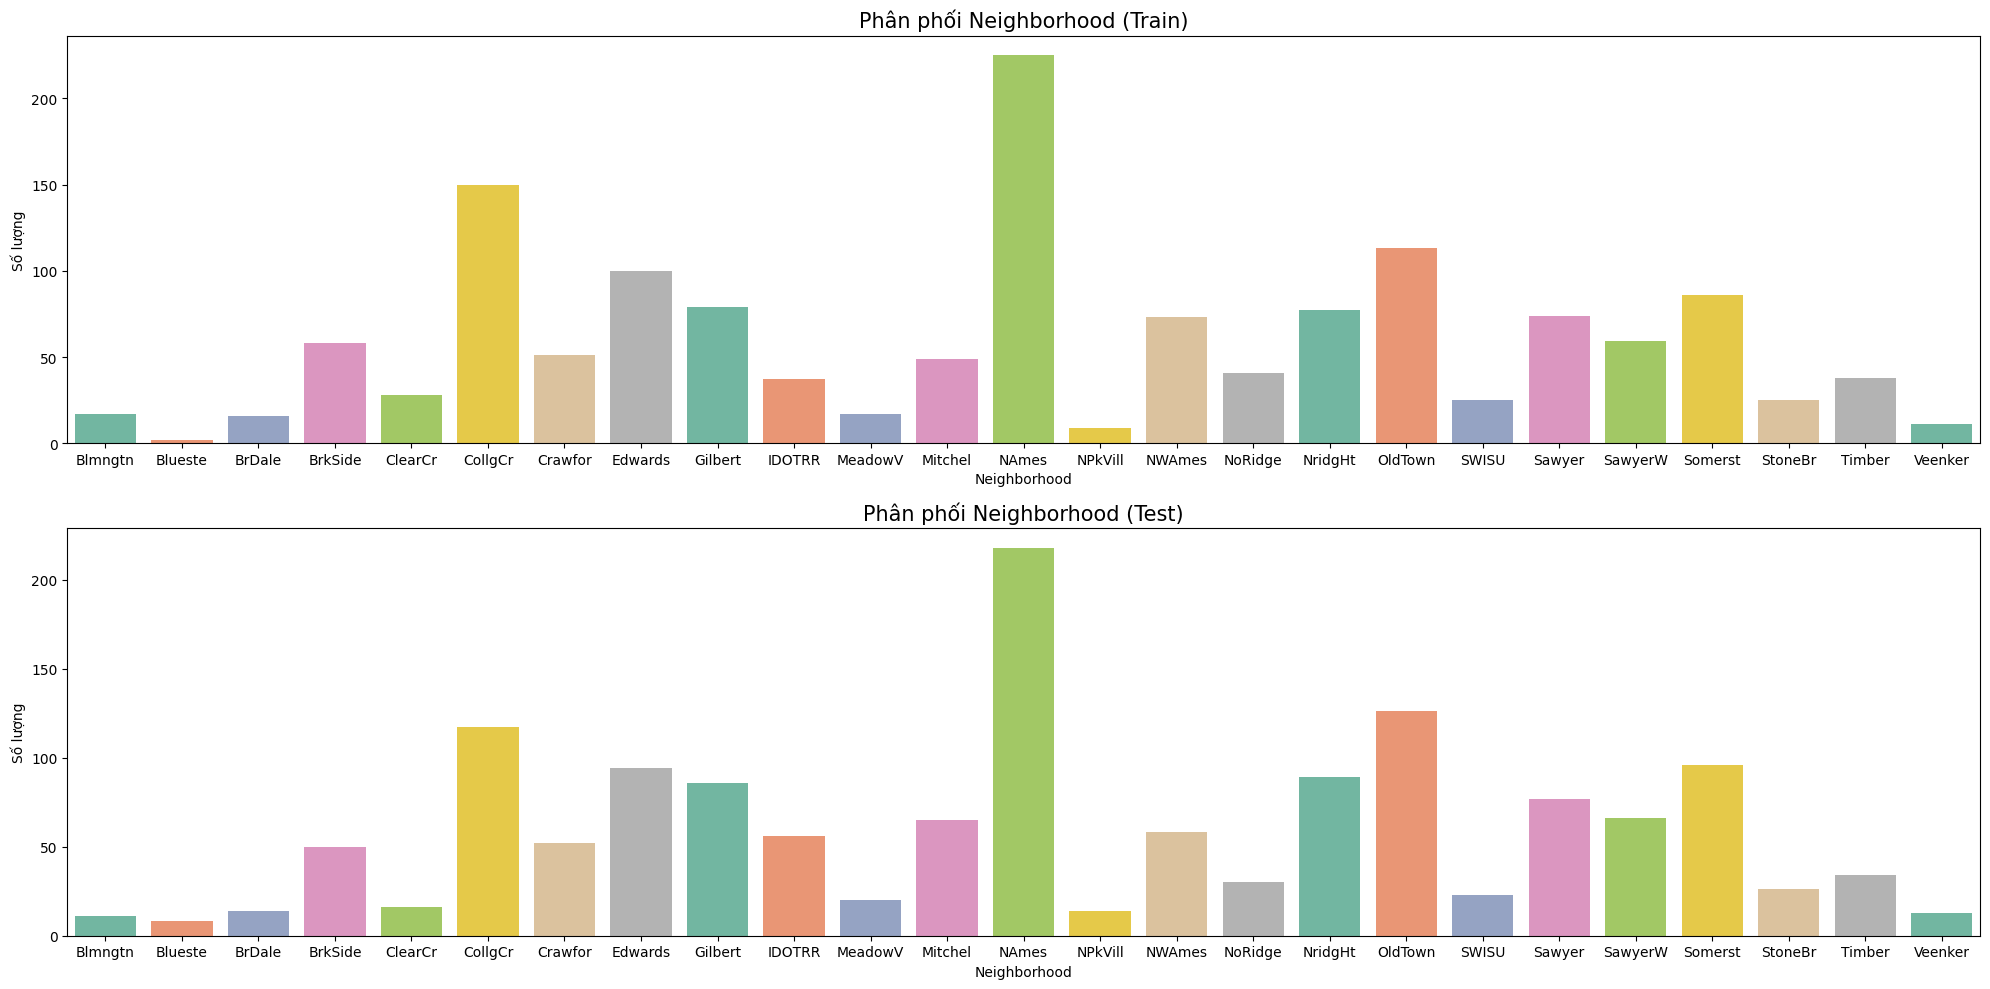

In [20]:
cols = ["Neighborhood"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(20, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 1, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột Neighborhood có 25 giá trị bao gồm (theo mô tả):
      
	+   Blmngtn: Bloomington Heights
	+   Blueste: Bluestem
	+   BrDale: Briardale
	+   BrkSide: Brookside
	+   ClearCr: Clear Creek
	+   CollgCr: College Creek
	+   Crawfor: Crawford
	+   Edwards: Edwards
	+   Gilbert: Gilbert
	+   IDOTRR: Iowa DOT and Rail Road
	+   MeadowV: Meadow Village
	+   Mitchel: Mitchell
	+   NAmes: North Ames
	+   NoRidge: Northridge
	+   NPkVill: Northpark Villa
	+   NridgHt: Northridge Heights
	+   NWAmes: Northwest Ames
	+   OldTown: Old Town
	+   SWISU: South & West of Iowa State University
	+   Sawyer: Sawyer
	+   SawyerW: Sawyer West
	+   Somerst: Somerset
	+   StoneBr: Stone Brook
	+   Timber: Timberland
	+   Veenker: Veenker

- Giá trị NAmes phân bố nhiều nhất, giá trị Blueste phân bố ít nhất.

##### g. Cột Condition1 và Condition2

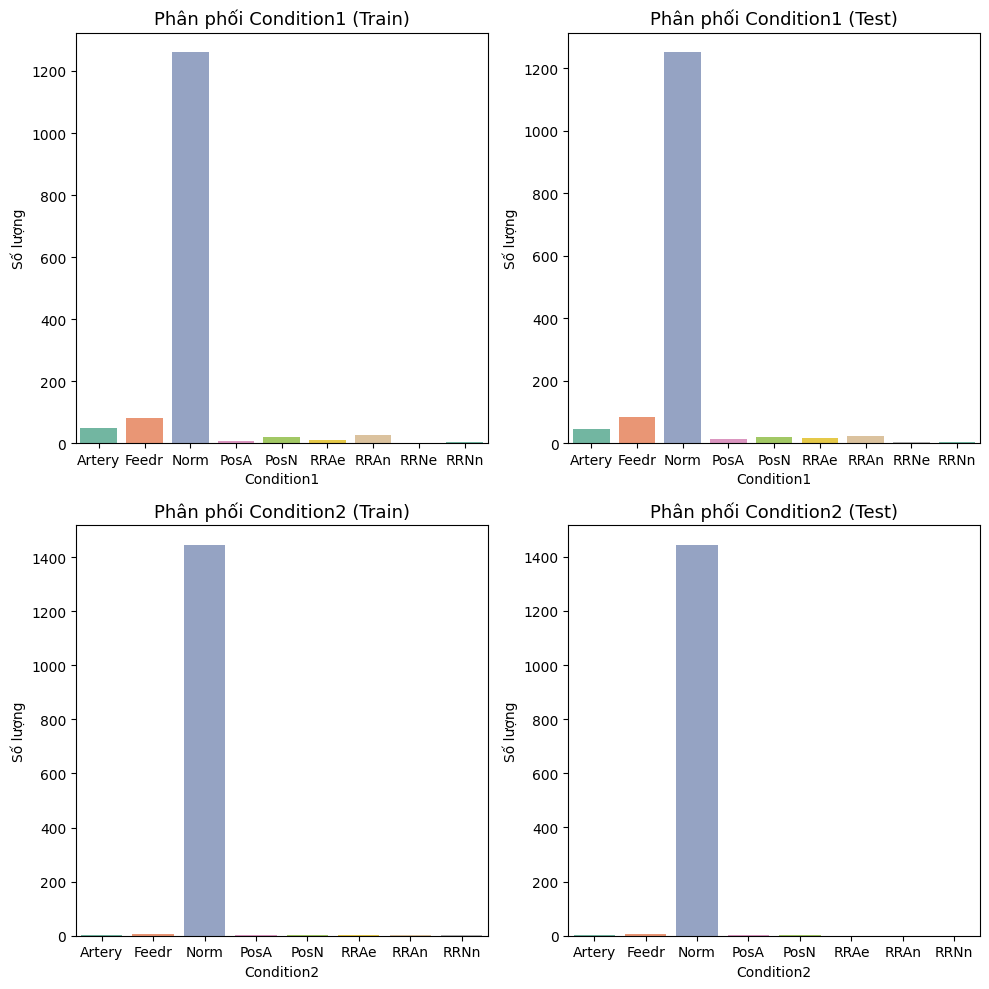

In [21]:
cols = ["Condition1", "Condition2"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột Condition1 có 8 giá trị bao gồm (theo mô tả):
	+ Artery: Bên cạnh đường huyết mạch.
	+ Feedr: Bên cạnh đường phụ song song với đường huyết mạch.
	+ Norm: Bình thường.
	+ RRNn: Nằm trong khoảng 200 feet từ đường ray Bắc-Nam.
	+ RRAn: Bên cạnh đường ray Bắc-Nam.
	+ PosN: Gần các tiện nghi như công viên, không gian xanh,...
	+ PosA: Bên cạnh các tiện nghi như công viên, không gian xanh,...
	+ RRNe: Nằm trong khoảng 200 feet từ đường ray Đông-Tây.
	+ RRAe	Bên cạnh đường ray đông tây.

- Cột Condition2 giống như cột Condition 1 nhưng không có phân bố giá trị RRNe.
- Cột Condition2 bổ sung thêm thuộc tính khi có Condition1 (có 2 thuộc tính).
- Giá trị Norm phân bố nhiều nhất, giá trị còn lại phân bố ít nhất.

##### h. Cột BldgType

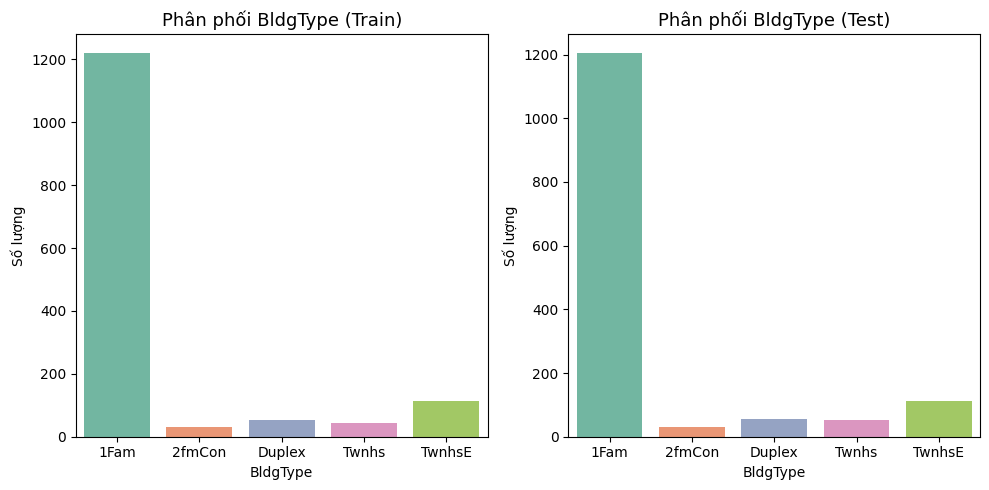

In [22]:
cols = ["BldgType"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 5))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(1, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột BldgType có 5 giá trị bao gồm (theo mô tả):
	+ 1Fam: Nhà riêng biệt, chỉ 1 hộ sinh sống.
	+ 2fmCon: Nhà đơn nhưng được chuyển thành 2 hộ.
	+ Duplex: Nhà song lập, 2 căn riêng biệt cùng 1 khối.
	+ Twnhs: Nhà liền kề, căn ở đầu dãy
	+ TwnhsE: Nhà liền kề, căn ở trong dãy.

- Giá trị 1Fam phân bố nhiều nhất, 2fmCon phân bố ít nhất.

##### i. Cột HouseStyle

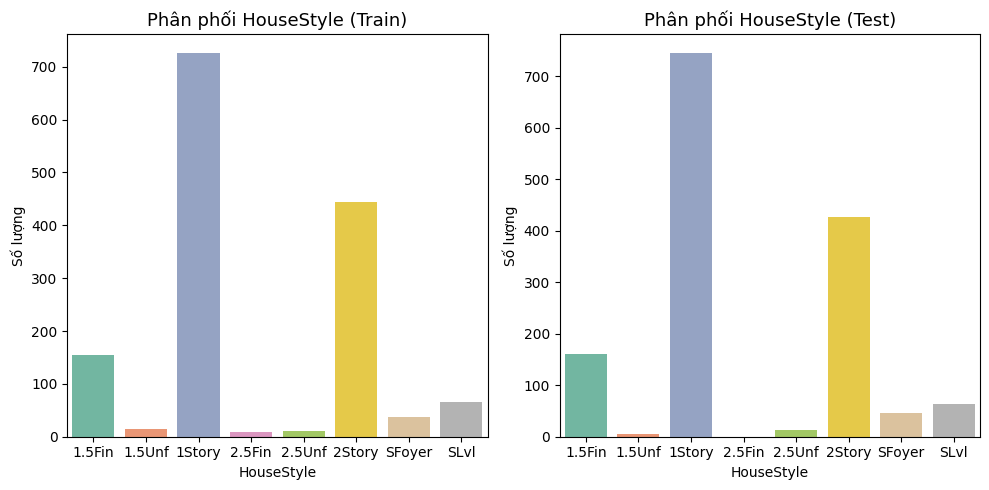

In [23]:
cols = ["HouseStyle"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 5))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(1, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột HouseStyle có 8 giá trị bao gồm (theo mô tả):
	+ 1Story: 1 tầng.
	+ 1.5Fin: 1,5 tầng. Gác lửng hoàn thiện.
	+ 1.5Unf: 1,5 tầng. Gác lửng chưa hoàn thiện.
	+ 2Story: 2 tầng.
	+ 2.5Fin: 2,5 tầng. Gác lửng hoàn thiện.
	+ 2.5Unf: 2,5 tầng. Gác lửng chưa hoàn thiện.
	+ SFoyer: Có lỗi vào chia tầng.
	+ SLvl: Có nhiều tầng lệch nhau.

- Giá trị 1Story phân bố nhiều nhất, tiếp theo là 2Story. Giá trị 1.5Unf, 2.5Unf và 2.5Fin phân bố ít nhất.

##### j. Cột RoofStyle và RoofMatl

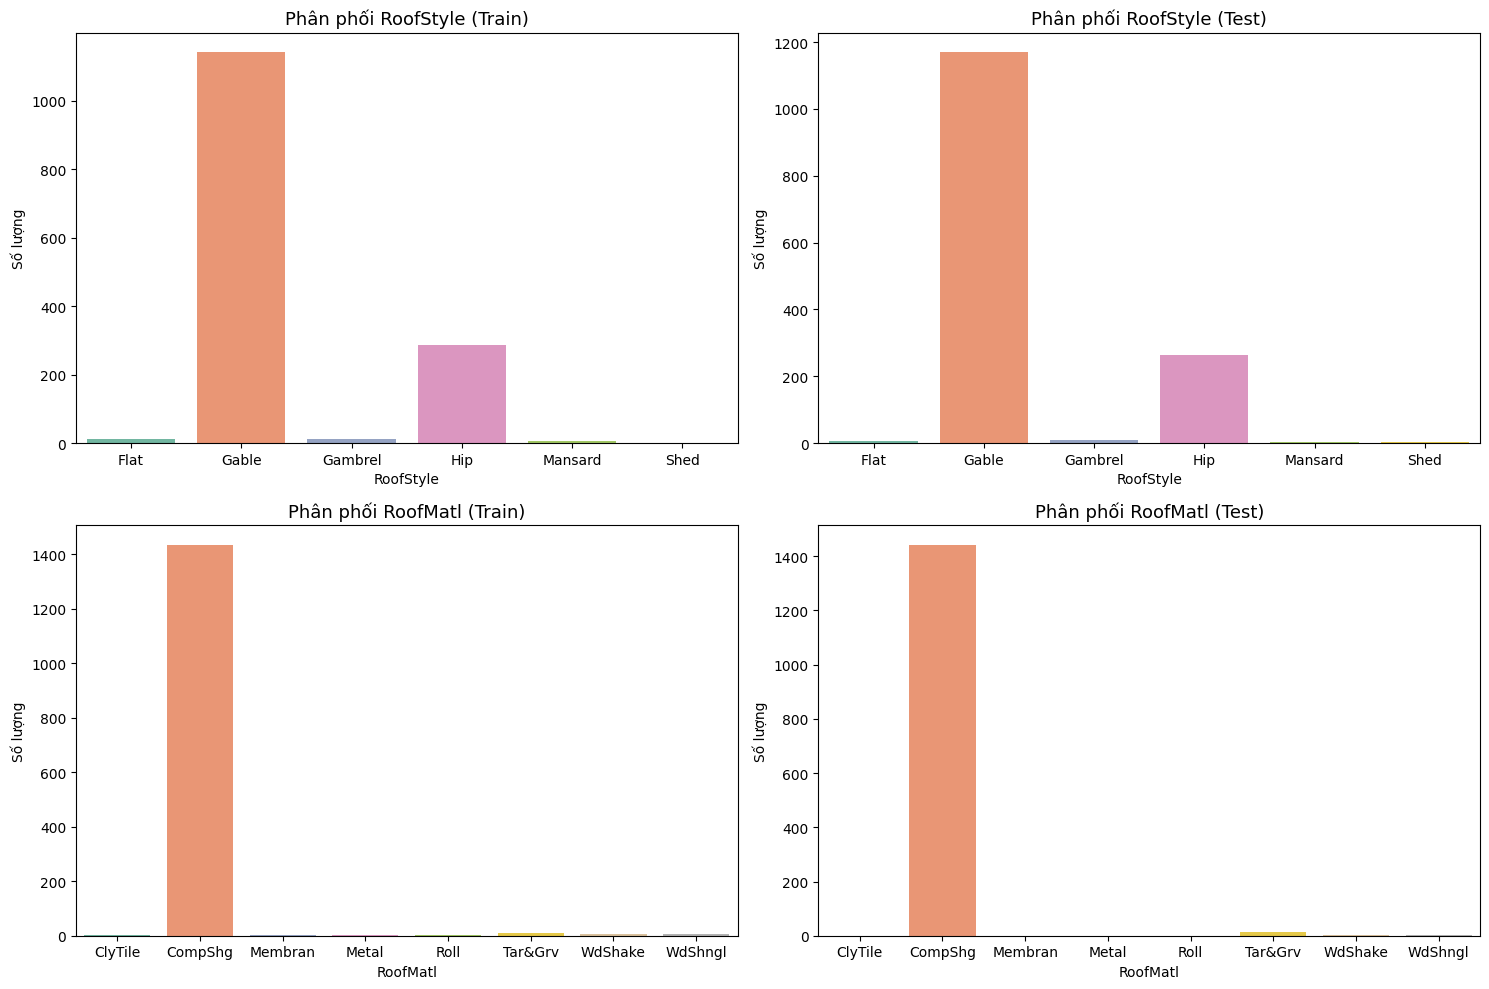

In [24]:
cols = ["RoofStyle", "RoofMatl"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(15, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=13)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột RoofStyle có 6 giá trị bao gồm (theo mô tả):
	+ Flat: Mái bằng.
	+ Gable: Mái hai dốc hình tam giác.
	+ Gambrel: Mái cong hai tầng.
	+ Hip: Mái bốn dốc.
	+ Mansard: Mái 4 dốc cong.
	+ Shed: Mái dốc đơn, nghiêng về 1 phía. 

- Cột RoofMatl có 8 giá trị bao gồm (theo mô tả):
	+ ClyTile: Đất sét hoặc ngói.
	+ ComShg: Tấm lớp composite tiêu chuẩn.
	+ Membrane: Tấm lớp màng.
	+ Metal: Kim loại.
	+ Roll: Tấm lớp nhựa bằng cuộn.
	+ Tar&Grv: Muội than và sỏi.
	+ WdShake: Tấm lớp gỗ.
	+ WdShngl: Tấm lớp gỗ ván.

- Giá trị Gable phân bố nhiều nhất, tiếp theo là Hip. Giá trị Flat, Gambrel, Mansard, Shed phân bố ít nhất.
- Giá trị ComShg phân bố nhiều nhất. Các giá trị còn lại phân bố ít nhất.

##### k. Cột Exterior1st, Exterior2nd

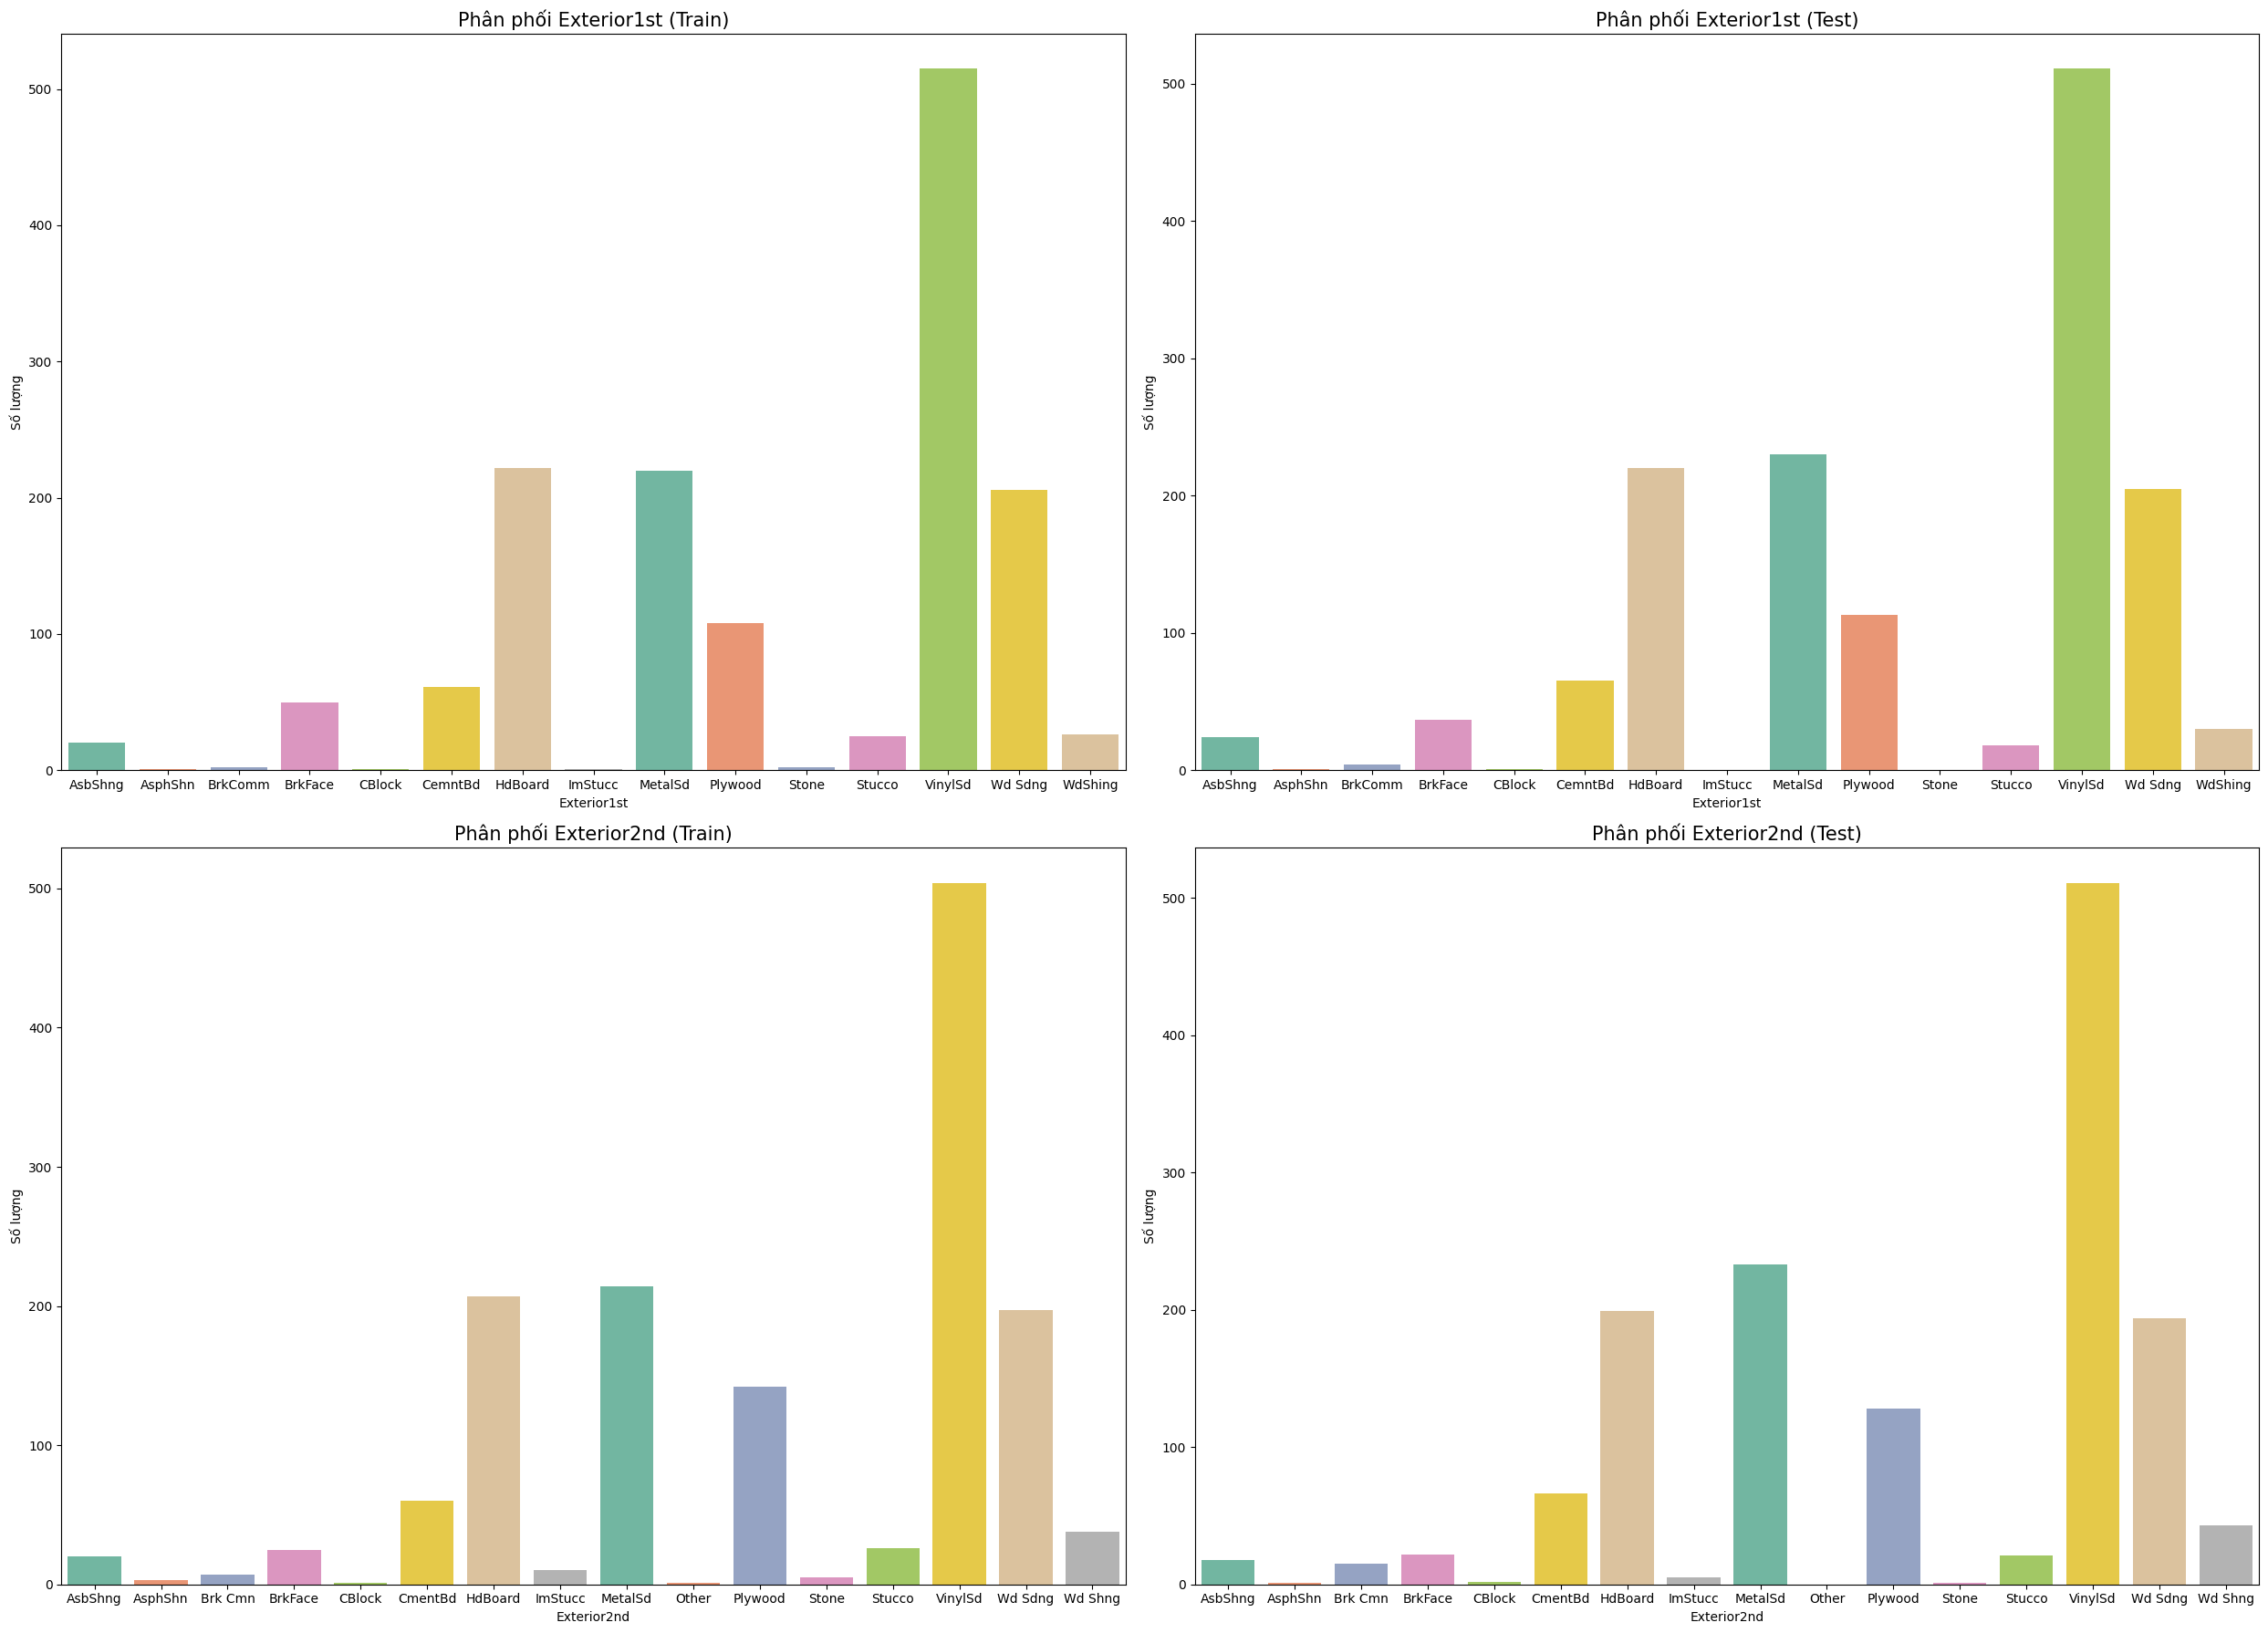

In [25]:
cols = ["Exterior1st", "Exterior2nd"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(25, 18))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột Exterior1st và Exterior2nd có  17 giá trị bao gồm (theo mô tả):
	+ AsbShng: Tấm amiăng (asbestos).
	+ AsphShn: Tấm nhựa đường.
	+ BrkComm: Gạch thường.
	+ BrkFace: Gạch ốp mặt ngoài.
	+ CBlock: Gạch bê tông rỗng.
	+ CemntBd: Tấm xi măng.
	+ HdBoard: Ván ép cứng (ván sợi nén).
	+ ImStucc: Tường giả vữa (stucco nhân tạo).
	+ MetalSd: Tấm ốp kim loại.
	+ Other: Khác.
	+ Plywood: Ván ép nhiều lớp.
	+ PreCast: Bê tông đúc sẵn.
	+ Stone: Đá tự nhiên hoặc nhân tạo.
	+ Stucco: Vữa trang trí ngoài.
	+ VinylSd: Tấm ốp nhựa Vinyl.
	+ Wd Sdng: Gỗ ốp tường.
	+ WdShing: Tấm gỗ lợp (vảy gỗ nhỏ chồng nhau).

- Giá trị Vinyl phân bố nhiều nhất. Giá trị  AsphShn, BrkComm, CBlock, ImStucc, Other, Stone phân bố ít nhất.

##### l. Cột MasVnrType

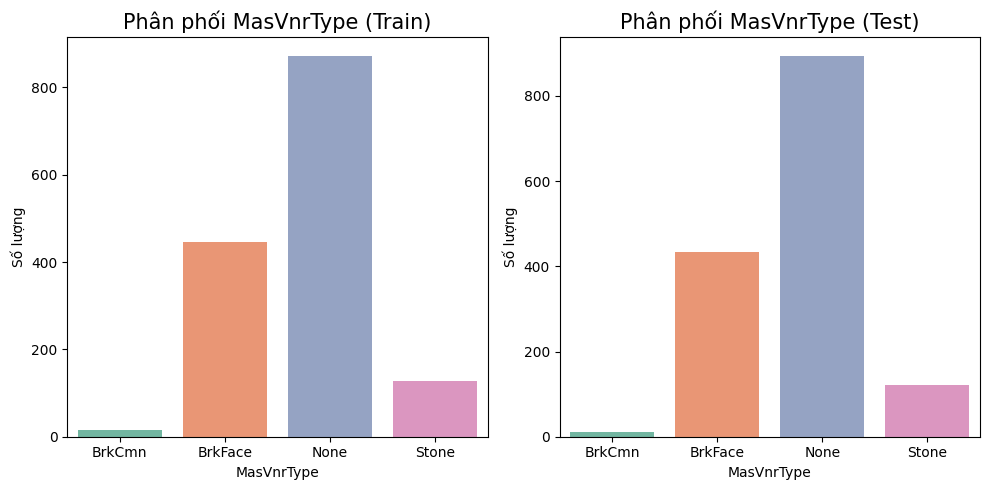

In [26]:
cols = ["MasVnrType"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 5))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(1, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột MasVnrType có  4 giá trị bao gồm (theo mô tả):
	+ BrkCmn: Gạch thường.
	+ BrkFace: Gạch ốp mặt ngoài.
	+ CBlock: Gạch bê tông rỗng.
	+ None: Không có lớp ốp.
	+ Stone: Đá tự nhiên hoặc nhân tạo.

- Giá trị None phân bố nhiều nhất. Giá trị BrkCmn phân bố ít nhất.

##### m. Cột ExterQual và ExterCond

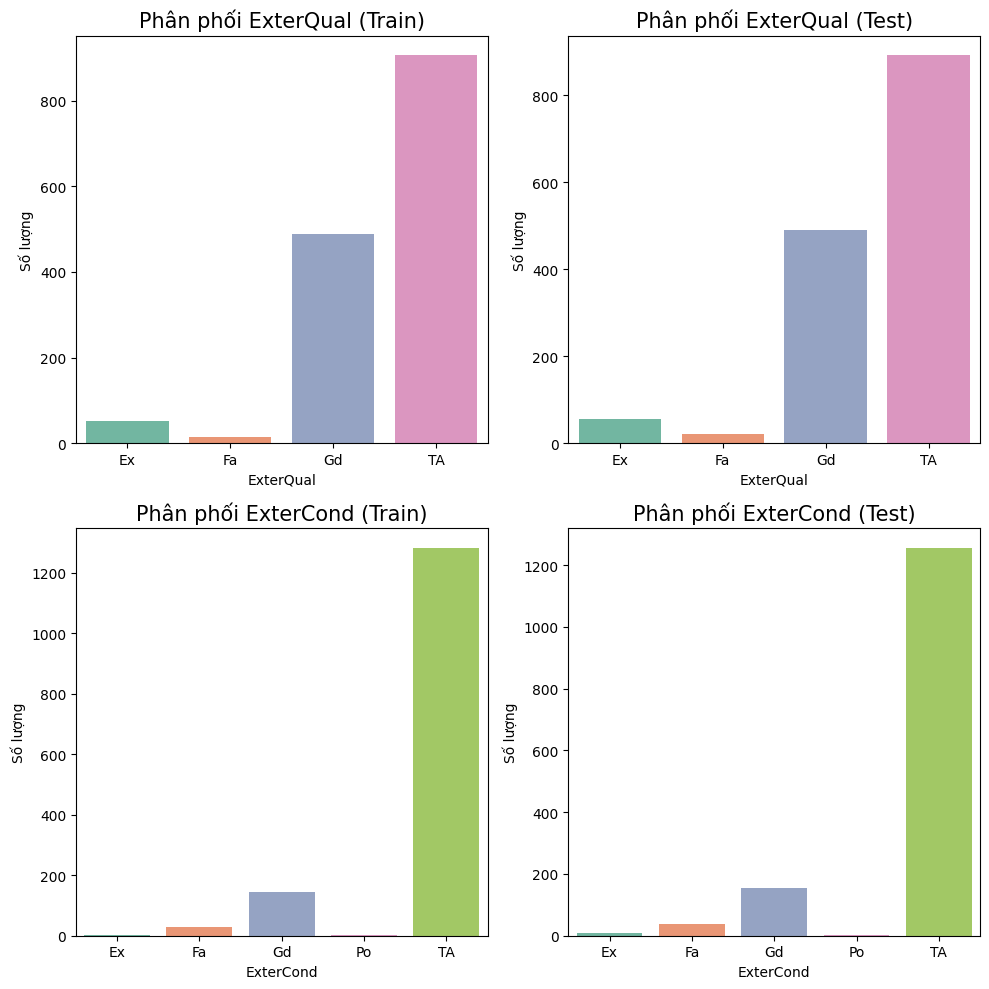

In [27]:
cols = ["ExterQual", "ExterCond"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột ExterQual có  5 giá trị bao gồm (theo mô tả):
	+ Ex: Xuất sắc.  
	+ Gd: Tốt.  
	+ TA: Trung bình.  
	+ Fa: Kém.  
	+ Po: Tệ (không có trong cột ExterCond).
- Cột ExterCond có  5 giá trị bao gồm (theo mô tả):
	+ Ex: Xuất sắc.  
	+ Gd: Tốt.  
	+ TA: Trung bình.  
	+ Fa: Kém.  
	+ Po: Tệ.

- Trong ExterQual, giá trị TA phân bố nhiều nhất. Giá trị Fa phân bố ít nhất.
- Trong ExterCond, giá trị TA phân bố nhiều nhất. Giá trị Po và Ex phân bố ít nhất.

##### n. Cột Foundation

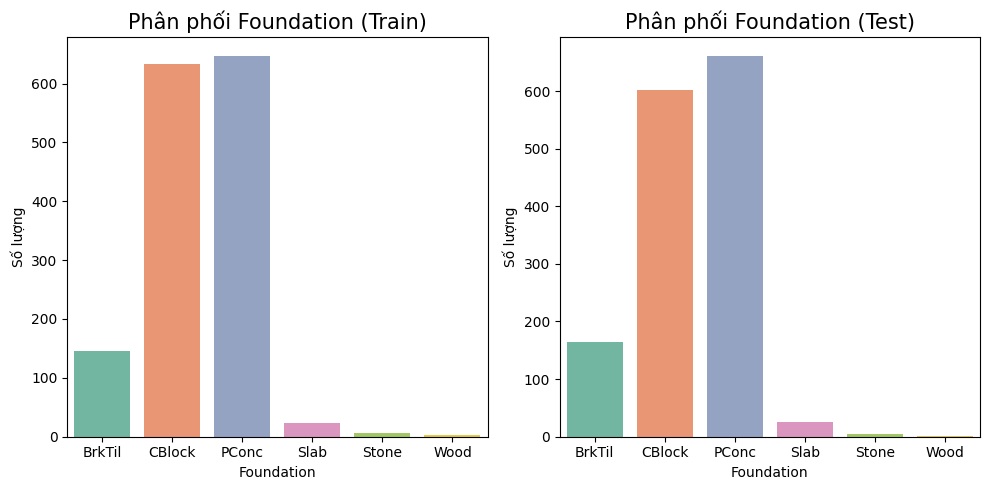

In [28]:
cols = ["Foundation"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 5))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(1, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột Foundation có  6 giá trị bao gồm (theo mô tả):
	+ BrkTil: Gạch và gạch lát.  
	+ CBlock: Khối bê tông (Cinder Block).  
	+ PConc: Bê tông đổ.  
	+ Slab: Nền tấm bê tông.  
	+ Stone: Đá.  
	+ Wood: Gỗ.

- Trong Foundation, giá trị CBlock và PConc phân bố nhiều nhất. Giá trị Stone và Wood phân bố ít nhất.

##### o. BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2

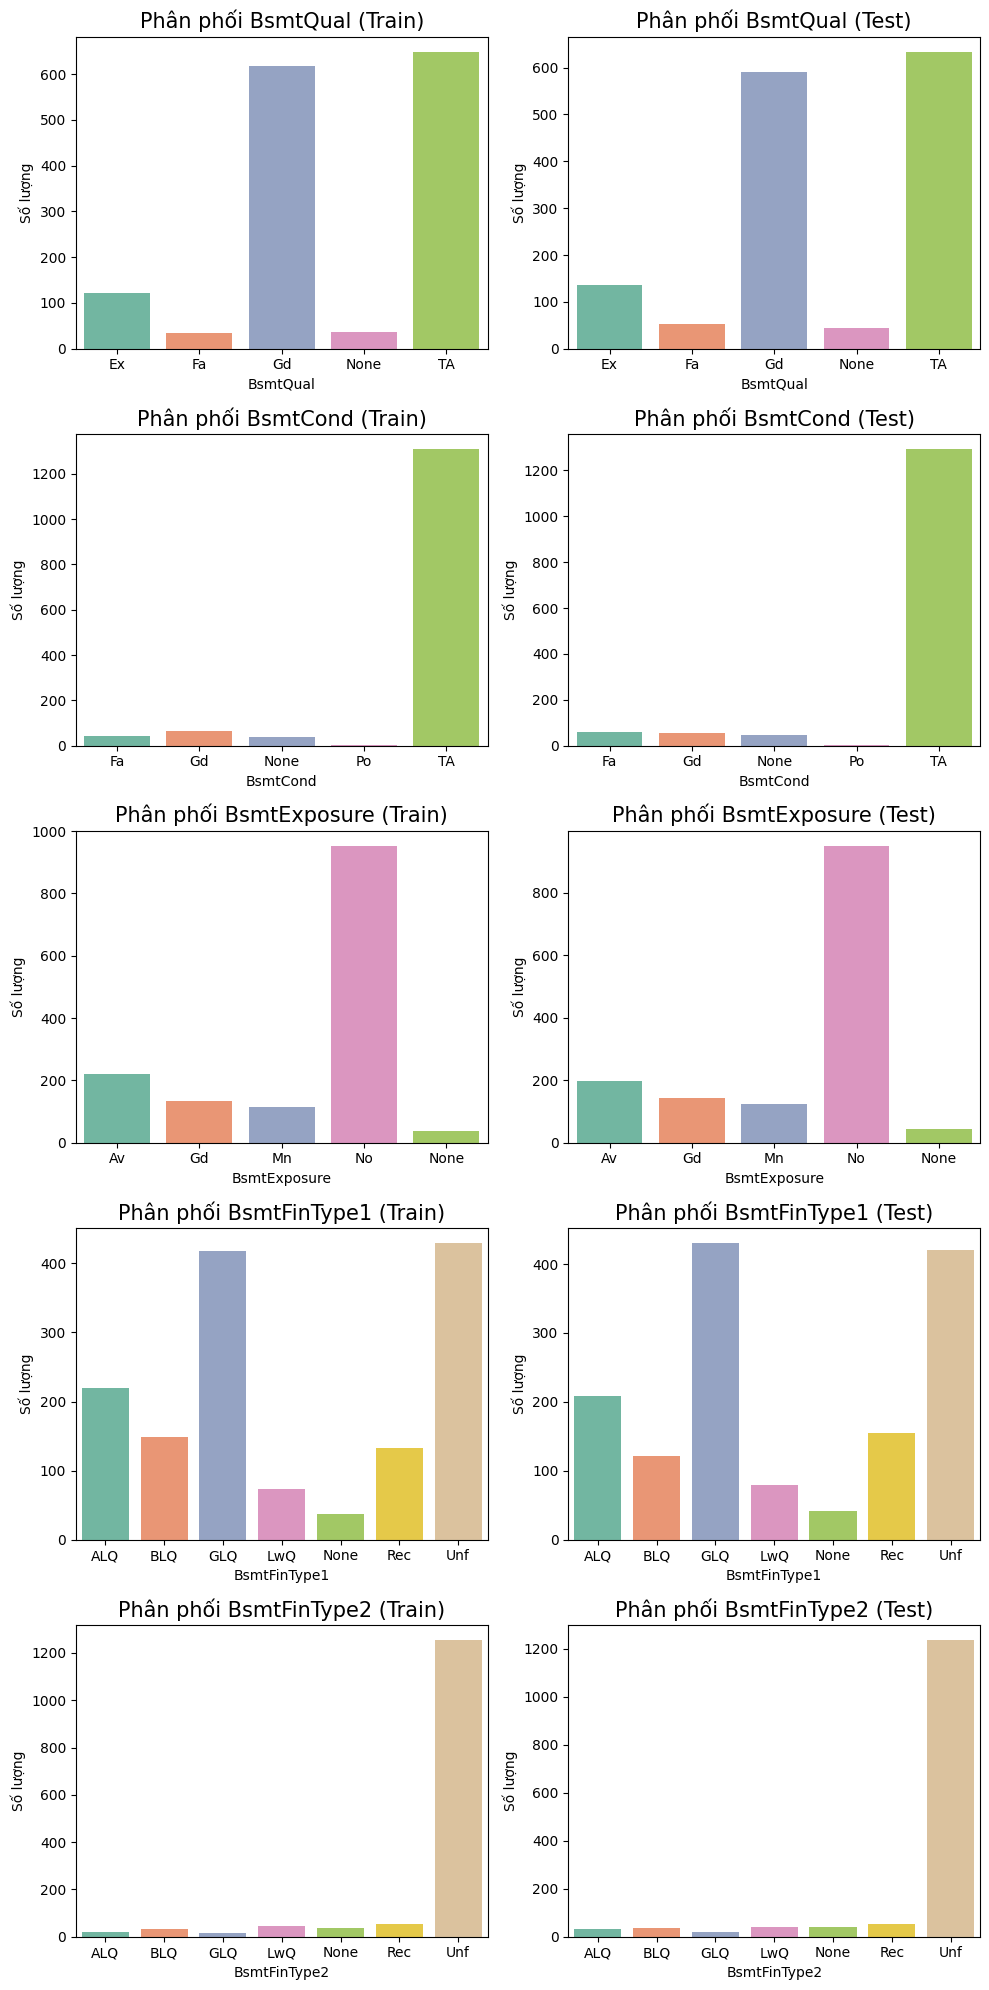

In [38]:
cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 20))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(5, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột BsmtQual có  6 giá trị bao gồm (theo mô tả):
  + Ex: Xuất sắc (≥ 100 inch)
  + Gd: Tốt (90–99 inch)
  + TA: Trung bình (80–89 inch)
  + Fa: Kém (70–79 inch)
  + Po: Rất kém (< 70 inch)
  + NA (None): Không có tầng hầm

- Cột BsmtCond có  6 giá trị bao gồm (theo mô tả):
  + Ex: Xuất sắc
  + Gd: Tốt
  + TA: Trung bình – cho phép hơi ẩm nhẹ
  + Fa: Kém – có ẩm ướt, nứt nhẹ hoặc lún
  + Po: Rất kém – nứt nghiêm trọng, lún mạnh hoặc thấm nước
  + NA (None): Không có tầng hầm

- Cột BsmtExposure có  5 giá trị bao gồm (theo mô tả):
  + Gd: Mở tốt (Good Exposure)
  + Av: Mở trung bình (Average Exposure) – thường gặp ở nhà tách tầng
  + Mn: Mở tối thiểu (Minimum Exposure)
  + No: Không có mở (No Exposure)
  + NA (None): Không có tầng hầm

- Cột BsmtFinType1 có  7 giá trị bao gồm (theo mô tả):
  + GLQ: Khu sinh hoạt chất lượng tốt (Good Living Quarters)
  + ALQ: Khu sinh hoạt trung bình (Average Living Quarters)
  + BLQ: Khu sinh hoạt dưới trung bình (Below Average Living Quarters)
  + Rec: Phòng giải trí trung bình (Average Rec Room)
  + LwQ: Chất lượng thấp (Low Quality)
  + Unf: Chưa hoàn thiện (Unfinished)
  + NA (None): Không có tầng hầm

- Cột BsmtFinType2 có  7 giá trị bao gồm (theo mô tả):
  + GLQ: Khu sinh hoạt chất lượng tốt (Good Living Quarters)
  + ALQ: Khu sinh hoạt trung bình (Average Living Quarters)
  + BLQ: Khu sinh hoạt dưới trung bình (Below Average Living Quarters)
  + Rec: Phòng giải trí trung bình (Average Rec Room)
  + LwQ: Chất lượng thấp (Low Quality)
  + Unf: Chưa hoàn thiện (Unfinished)
  + NA (None): Không có tầng hầm

- Ở cột BsmtQual, giá trị Gd và TA có số lượng nhiều nhất, FA và None (NA) có số lượng thấp nhất.
- Ở cột BsmtCond, giá trị TA có số lượng nhiều nhất, Po có số lượng thấp nhất.
- Ở cột BsmtExposure, giá trị No có số lượng nhiều nhất, None (NA) có số lượng thấp nhất.
- Ở cột BsmtFinType1, giá trị GLQ, Unf có số lượng nhiều nhất, None (NA) có số lượng thấp nhất.
- Ở cột BsmtFinType2, giá trị Unf có số lượng nhiều nhất, các cột còn lại có số lượng thấp nhất.

##### p. Cột Heating và HeatingQC

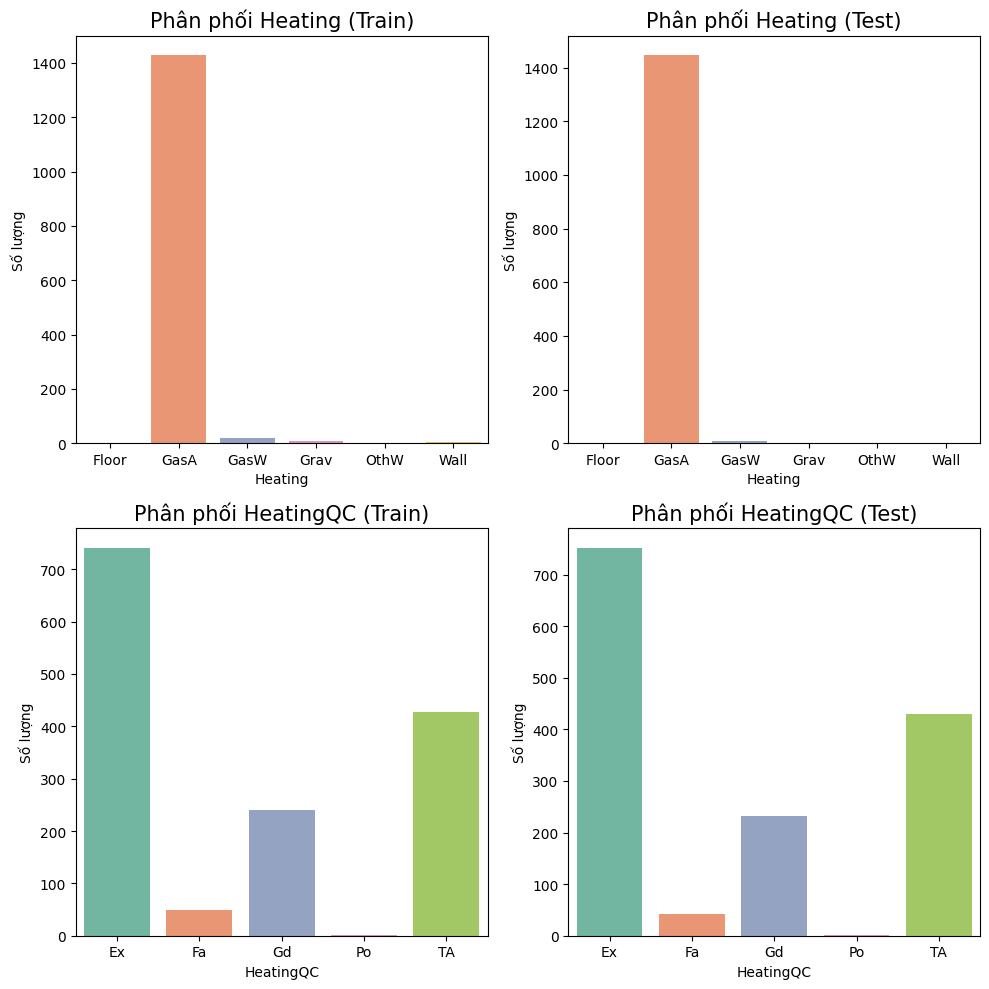

In [39]:
cols = ["Heating", "HeatingQC"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**:
- Cột Heating có  6 giá trị bao gồm (theo mô tả):
  + Floor: Lò sưởi sàn (Floor Furnace)
  + GasA: Lò sưởi khí đốt – tuần hoàn không khí nóng (Gas forced warm air furnace)
  + GasW: Lò sưởi khí đốt – nước nóng hoặc hơi nước (Gas hot water or steam heat)
  + Grav: Lò sưởi đối lưu tự nhiên (Gravity furnace)
  + OthW: Hệ thống sưởi bằng nước nóng hoặc hơi nước (không dùng khí đốt)
  + Wall: Lò sưởi gắn tường (Wall furnace)

- Cột HeatingQC có  5 giá trị bao gồm (theo mô tả):
  + Ex: Xuất sắc
  + Gd: Tốt
  + TA: Trung bình / điển hình
  + Fa: Kém
  + Po: Rất kém

- Ở cột Heating, giá trị GasA có số lượng nhiều nhất, các cột còn lại có số lượng thấp nhất.
- Ở cột HeatingQC, giá trị Ex có số lượng nhiều nhất, Po có số lượng thấp nhất.

##### q. Cột CentralAir và Electrical

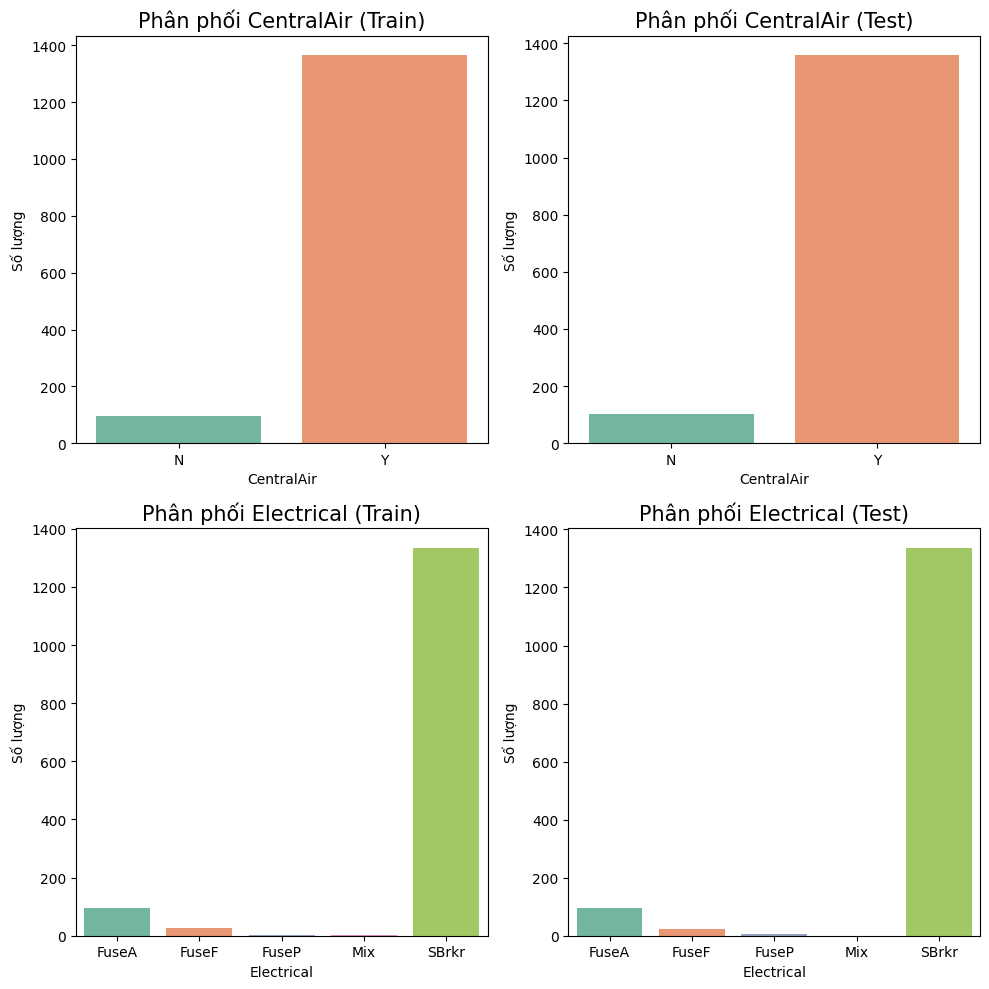

In [42]:
cols = ["CentralAir", "Electrical"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**:
- Cột CentralAir có  2 giá trị bao gồm (theo mô tả):
    + N: Không có 
    + Y: Có
		
- Cột Electrical có  5 giá trị bao gồm (theo mô tả)
	+ SBrkr: Cầu dao tự động tiêu chuẩn & dây Romex
	+ FuseA: Hộp cầu chì trên 60 AMP, toàn bộ dây Romex (Trung bình)
	+ FuseF: Hộp cầu chì 60 AMP, chủ yếu dây Romex (Khá)
	+ FuseP: Hộp cầu chì 60 AMP, chủ yếu dây núm & ống (Kém)
	+ Mix: Hệ thống điện pha trộn (Mixed)

- Ở cột CentralAir, giá trị Y có số lượng nhiều nhất, giá trị N có số lượng thấp nhất.
- Ở cột Electrical, giá trị SBrkr có số lượng nhiều nhất, giá trị FuseP và Mix có số lượng thấp nhất.

##### r. Cột KitchenQual và FireplaceQu

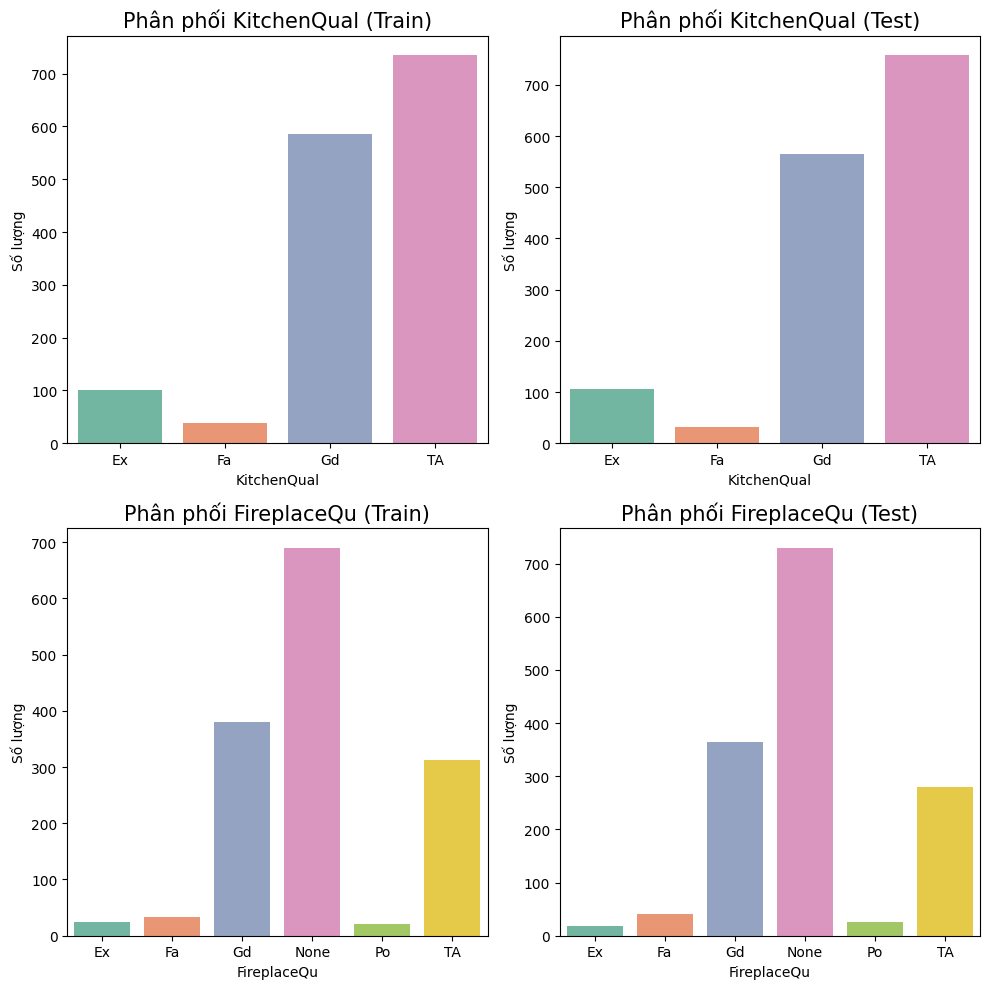

In [43]:
cols = ["KitchenQual", "FireplaceQu"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**:
- Cột KitchenQual có  5 giá trị bao gồm (theo mô tả):
	+ Ex: Xuất sắc
	+ Gd: Tốt
	+ TA: Trung bình / Điển hình
	+ Fa: Kém
	+ Po: Rất kém

- Cột FireplaceQu có  6 giá trị bao gồm (theo mô tả):
  + Ex: Xuất sắc – Lò sưởi xây gạch đặc biệt
  + Gd: Tốt – Lò sưởi xây gạch ở tầng chính
  + TA: Trung bình – Lò sưởi lắp sẵn ở phòng chính hoặc lò xây gạch ở tầng hầm
  + Fa: Kém – Lò sưởi lắp sẵn ở tầng hầm
  + Po: Rất kém – Lò sưởi kiểu Ben Franklin
  + NA: Không có lò sưởi

- Ở cột KitchenQual, giá trị TA có số lượng nhiều nhất, giá trị Fa có số lượng thấp nhất.
- Ở cột FireplaceQu, giá trị None có số lượng nhiều nhất, giá trị Ex và Po có số lượng thấp nhất.

##### s. Cột Functional

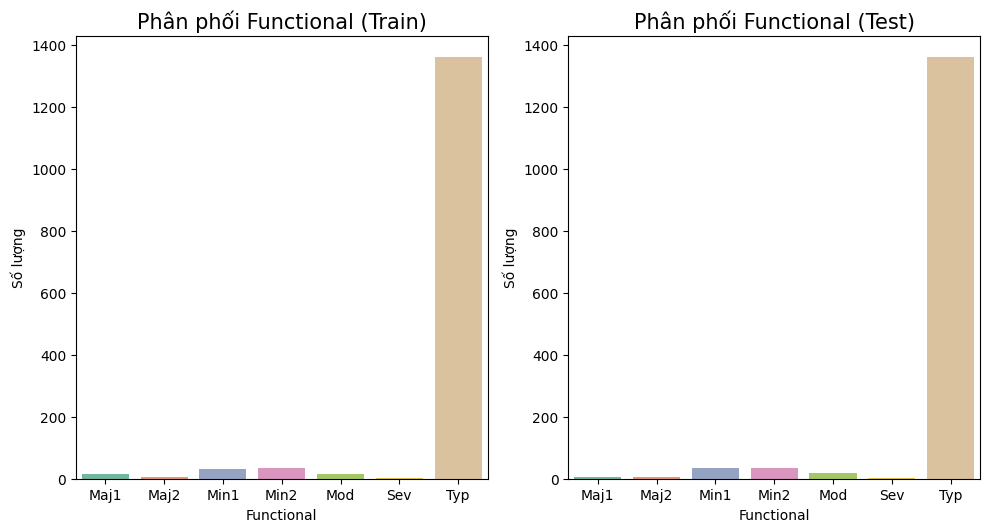

In [44]:
cols = ["Functional"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**:
- Cột Functional có  2 giá trị bao gồm (theo mô tả):
  + Typ: Chức năng bình thường
  + Min1: Giảm giá trị nhỏ mức 1
  + Min2: Giảm giá trị nhỏ mức 2
  + Mod: Giảm giá trị trung bình
  + Maj1: Giảm giá trị lớn mức 1
  + Maj2: Giảm giá trị lớn mức 2
  + Sev: Hư hại nghiêm trọng
  + Sal: Chỉ có thể tận dụng phần còn lại (phế phẩm)

- Giá trị Type có số lượng nhiều nhất, các giá trị khác có số lượng thấp nhất.


##### t. Các cột GarageType, GarageFinish, GarageQual, GarageCond

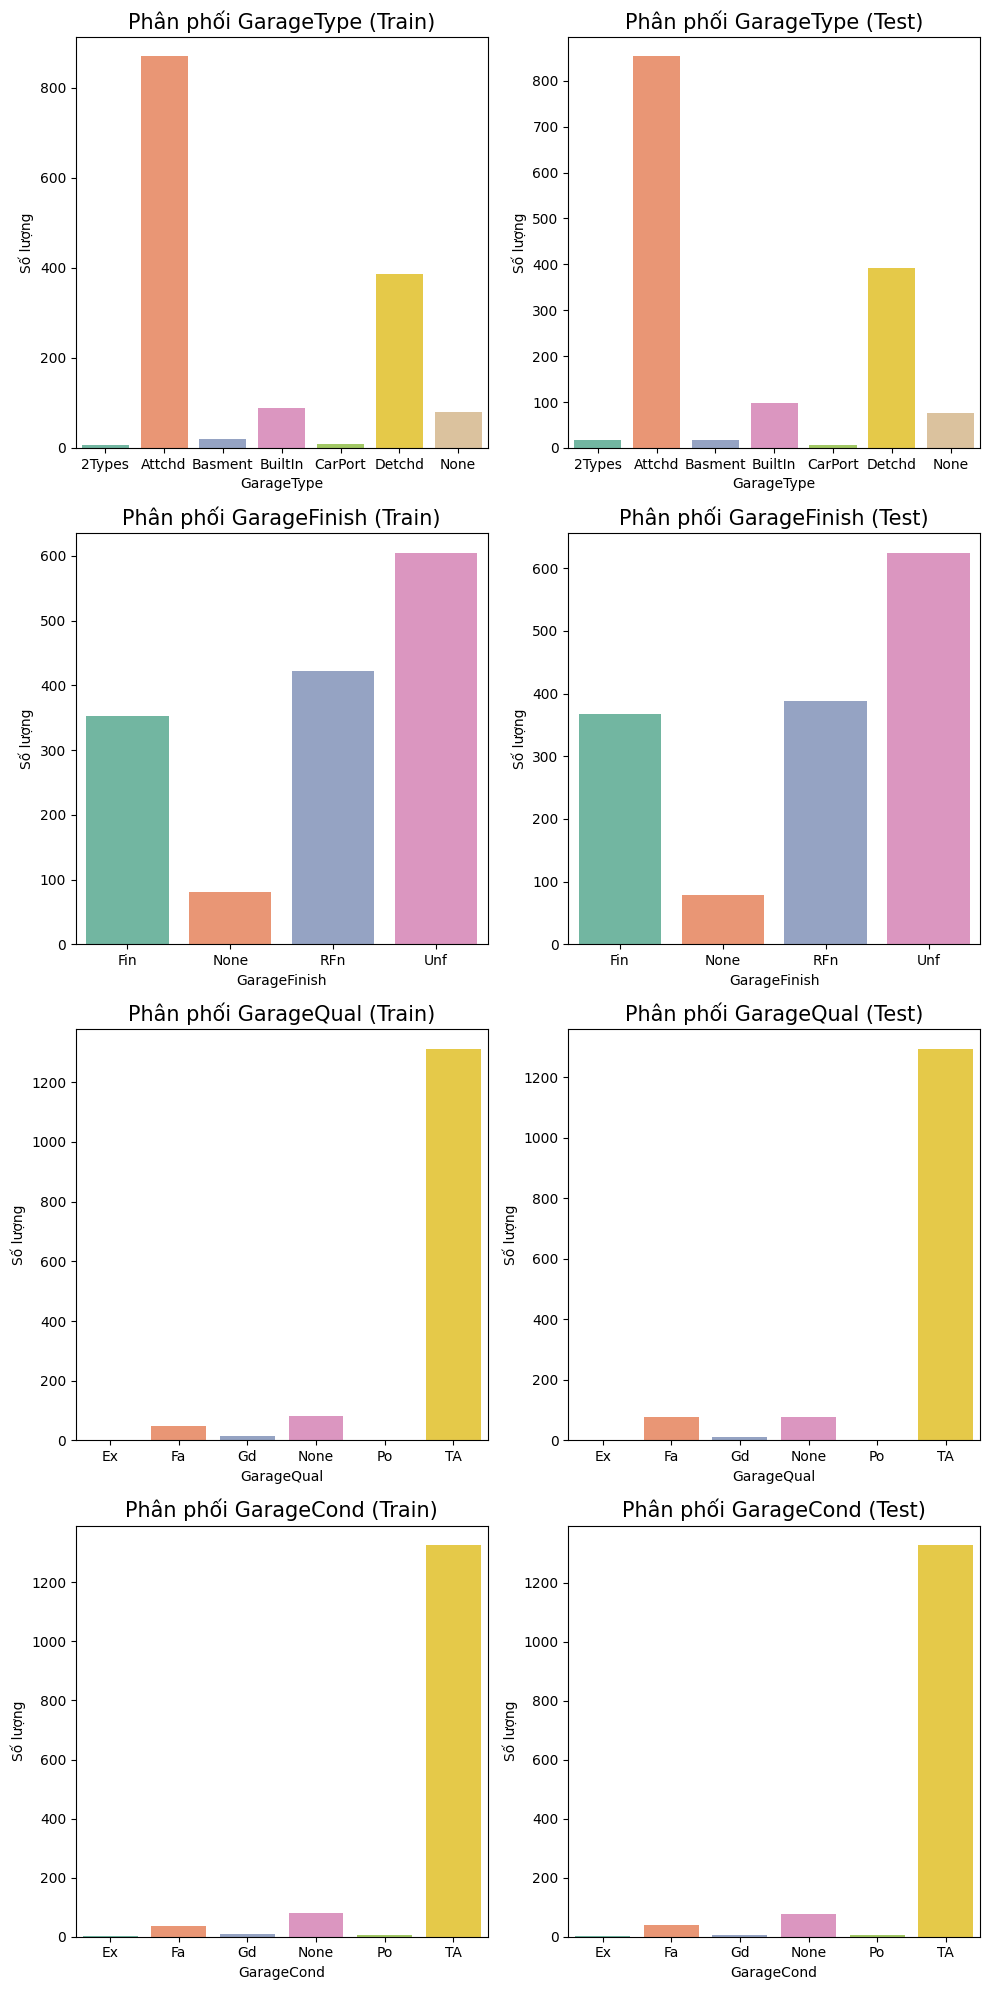

In [48]:
cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 20))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(4, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**:
- Cột GarageType có  7 giá trị bao gồm (theo mô tả):
  + 2Types: Có hơn một loại gara
  + Attchd: Gắn liền với nhà
  + Basment: Gara nằm trong tầng hầm
  + BuiltIn: Gara tích hợp trong cấu trúc nhà (thường có phòng phía trên)
  + CarPort: Mái che xe (không kín)
  + Detchd: Gara tách rời khỏi nhà
  + NA: Không có gara

- Cột GarageFinish có  7 giá trị bao gồm (theo mô tả):
  + Fin: Hoàn thiện đầy đủ
  + RFn: Hoàn thiện thô
  + Unf: Chưa hoàn thiện
  + NA: Không có gara

- Cột GarageQual có  7 giá trị bao gồm (theo mô tả):
  + Ex: Xuất sắc
  + Gd: Tốt
  + TA: Trung bình / điển hình
  + Fa: Kém
  + Po: Rất kém
  + NA: Không có gara

- Cột GarageCond có  7 giá trị bao gồm (theo mô tả):
  + Ex: Xuất sắc
  + Gd: Tốt
  + TA: Trung bình / điển hình
  + Fa: Kém
  + Po: Rất kém
  + NA: Không có gara
  
- Ở cột GarageType, giá trị Attchd có số lượng nhiều nhất, các giá trị 2Type, CarPort và Basment có số lượng thấp nhất.
- Ở cột GarageFinish, giá trị Unf có số lượng nhiều nhất, giá trị None(NA) có số lượng thấp nhất.
- Ở cột GarageQual, giá trị TA có số lượng nhiều nhất, các giá trị Ex, Gd, Po có số lượng thấp nhất.
- Ở cột GarageCond, giá trị TA có số lượng nhiều nhất, các giá trị Ex, Gd, Po có số lượng thấp nhất.

##### u. Các cột PoolQC, Fence, MiscFeature

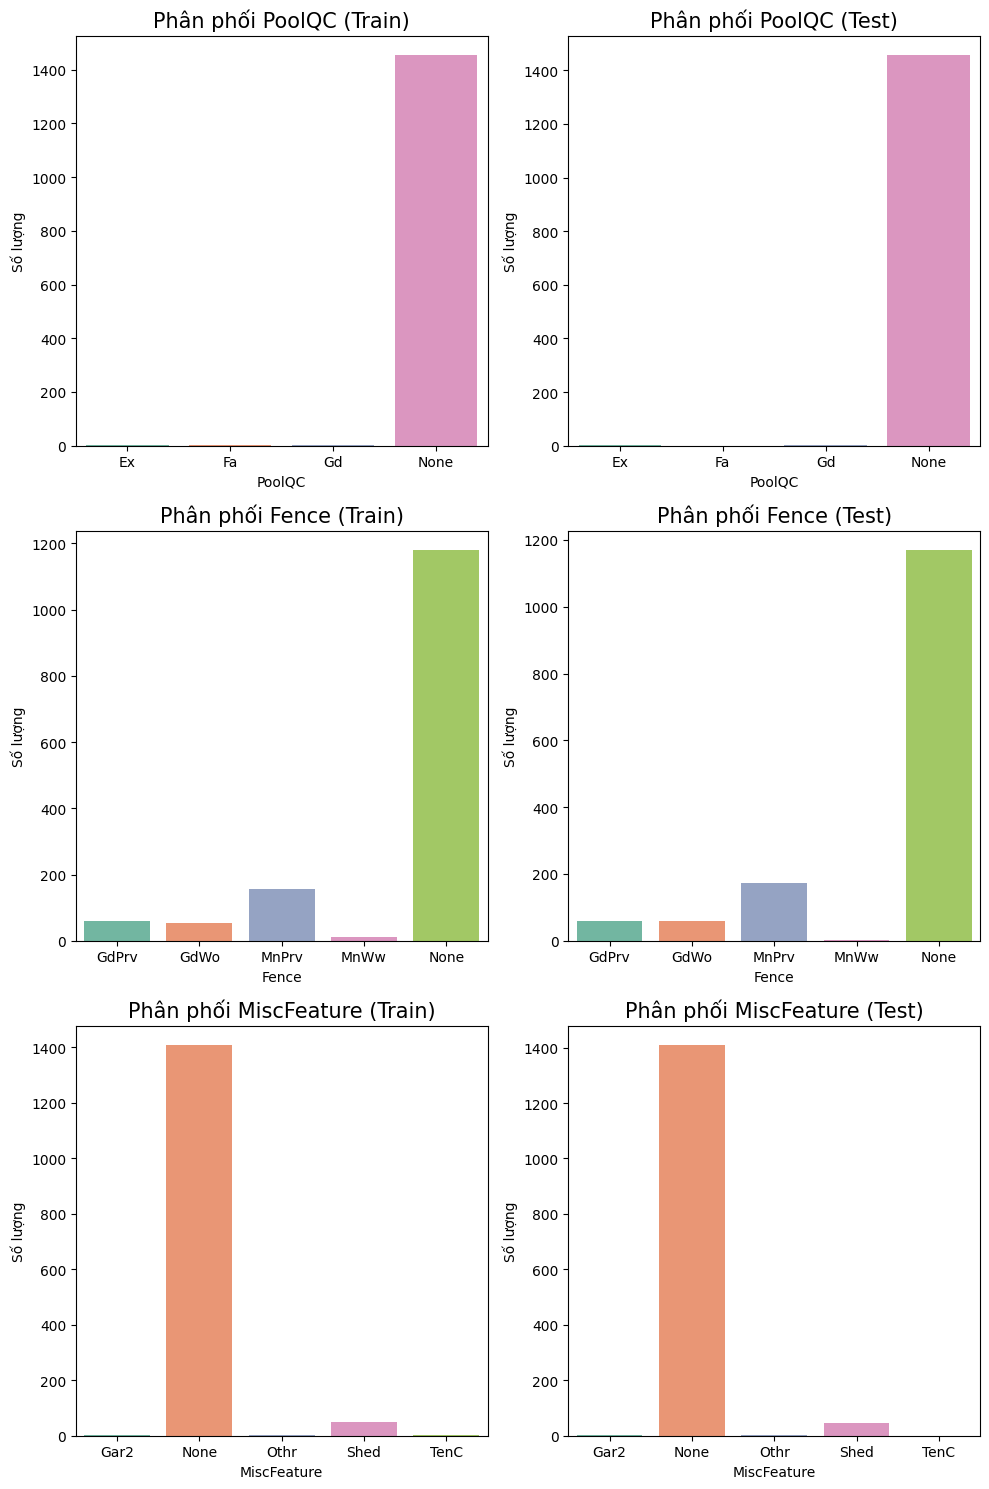

In [51]:
cols = ["PoolQC", "Fence", "MiscFeature"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 15))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(3, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**:
- Cột PoolQC có  5 giá trị bao gồm (theo mô tả):
  + Ex: Xuất sắc
  + Gd: Tốt
  + TA: Trung bình / điển hình
  + Fa: Kém
  + NA: Không có hồ bơi

- Cột Fence có  5 giá trị bao gồm (theo mô tả):
  + GdPrv: Hàng rào riêng tư tốt
  + MnPrv: Hàng rào riêng tư tối thiểu
  + GdWo: Hàng rào gỗ tốt
  + MnWw: Hàng rào gỗ / dây tối thiểu
  + NA: Không có hàng rào

- Cột MiscFeature có  6 giá trị bao gồm (theo mô tả):
  + Elev: Thang máy
  + Gar2: Gara thứ hai (nếu không mô tả trong phần gara)
  + Othr: Khác
  + Shed: Nhà kho (trên 100 ft²)
  + TenC: Sân tennis
  + NA: Không có đặc điểm khác

- Ở cột PoolQC, giá trị Unf có số lượng nhiều nhất, giá trị None(NA) có số lượng thấp nhất.
- Ở cột Fence, giá trị None (NA) có số lượng nhiều nhất, giá trị MnWw có số lượng thấp nhất.
- Ở cột MiscFeature, giá trị None(NA) có số lượng nhiều nhất, giá trị Shed có số lượng lớn thứ hai, các giá trị còn lại có số lượng thấp nhất.


##### v. Các cột SaleType và SaleCondition

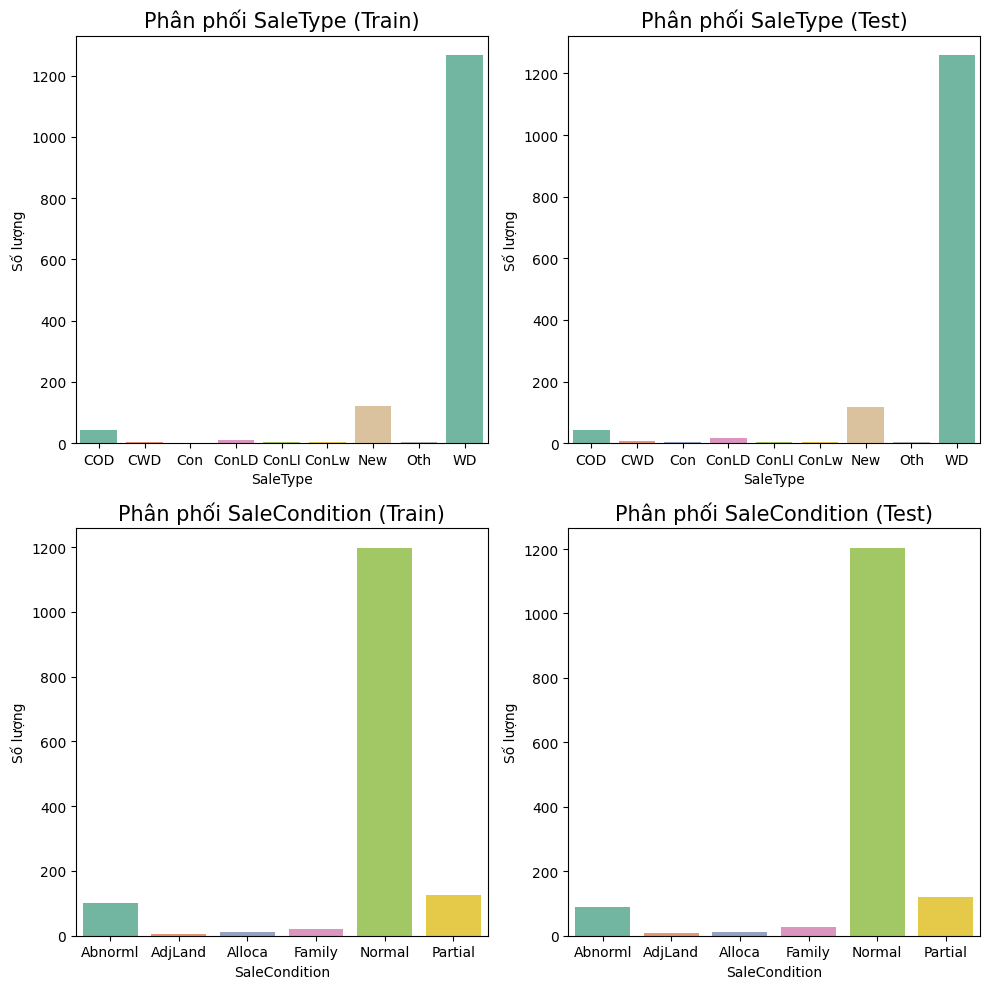

In [53]:
cols = ["SaleType", "SaleCondition"]
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(10, 10))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(2, 2, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.show()

**Nhận xét**
- Cột SaleType có  10 giá trị bao gồm (theo mô tả):
	+ WD: Warranty Deed – Bán thông thường có bảo hành
	+ CWD: Warranty Deed – Thanh toán tiền mặt
	+ VWD: Warranty Deed – Theo chương trình VA Loan
	+ New: Nhà mới xây và được bán lần đầu
	+ COD: Court Officer Deed/Estate – Bán do tòa án hoặc tài sản thừa kế
	+ Con: Hợp đồng mua với 15% đặt cọc, điều khoản bình thường
	+ ConLw: Hợp đồng đặt cọc thấp và lãi suất thấp
	+ ConLI: Hợp đồng lãi suất thấp
	+ ConLD: Hợp đồng đặt cọc thấp
	+ Oth: Khác 

- Cột SaleCondition có  6 giá trị bao gồm (theo mô tả):
	+ Normal: Giao dịch bình thường
	+ Abnorml: Giao dịch bất thường (trao đổi, tịch thu, bán tháo, v.v.)
	+ AdjLand: Mua đất liền kề
	+ Alloca: Allocation – Hai tài sản liên kết có sổ riêng (ví dụ: căn hộ + gara)
	+ Family: Bán giữa các thành viên trong gia đình
	+ Partial: Nhà chưa hoàn thiện khi được định giá (thường gặp ở nhà mới)                       
	
- Ở cột SaleType, giá trị WD có số lượng nhiều nhất, các giá trị khác có số lượng thấp nhất.
- Ở cột SaleCondition, giá trị Normal có số lượng nhiều nhất, giá trị AdjLand có số lượng thấp nhất.


##### w. Hiện tất cả các cột phi số

In [ ]:
cols = train_data.select_dtypes(include=["object"]).columns
datasets = [("Train", train_data), ("Test", test_data)]

plt.figure(figsize=(100, 100))

plot_idx = 1
for col in cols:
    # Xác định thứ tự và bảng màu chung cho từng cột
    common_order = sorted(set(train_data[col]).union(test_data[col]))
    base_colors = sns.color_palette("Set2", n_colors=len(common_order))
    color_map = dict(zip(common_order, base_colors))

    for name, df in datasets:
        plt.subplot(10, 9, plot_idx)
        sns.countplot(
            x=col,
            data=df,
            order=common_order,
            hue=col,
            palette=color_map,
            legend=False
        )
        plt.title(f"Phân phối {col} ({name})", fontsize=15)
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plot_idx += 1

plt.tight_layout()
plt.savefig("fig_hist_1b.png")
plt.show()